# 🚍 GTFS Diagnostics — Operational Intelligence Report

> A comprehensive diagnostic analysis of a GTFS transit feed,
> extracting operational metrics, spatial patterns, and service quality
> indicators from schedule data.

### Contents

| # | Section | Key outputs |
|---|---|---|
| 1 | **Setup & Feed Overview** | Table counts, date range, agency info |
| 2 | **Service Profile** | Active trips over the day (10-min bins) |
| 3 | **Stop-level Analysis** | Headway & frequency maps, busiest stops |
| 4 | **Route Corridors** | Segment-level route concentration |
| 5 | **Service Kilometres** | Daily VKT, distance by route and time window |
| 6 | **Trip Summary Table** | Trips × time window, km/trip, total km |
| 7 | **Diagnostics** | Speed anomalies, stop spacing, trip duration outliers |

---
## 0 — Configuration

In [30]:
# ── Point this to your GTFS feed ─────────────────────────────────────
GTFS_PATH = "../data/processed/20260325_183744/gtfs.zip"

# Analysis date (None = auto-detect busiest date)
ANALYSIS_DATE: str | None = None

# Time windows for summary tables (hours)
TIME_WINDOWS = [
    ("Madrugada",  "00:00:00", "05:00:00"),
    ("Manhã Pico", "05:00:00", "09:00:00"),
    ("Entrepico",  "09:00:00", "16:00:00"),
    ("Tarde Pico",  "16:00:00", "20:00:00"),
    ("Noite",       "20:00:00", "24:00:00"),
]

# Headway computation window
HEADWAY_START = "06:00:00"
HEADWAY_END   = "22:00:00"

# CRS for distance calculations (UTM zone for your city)
# Set to None for auto-detection
LOCAL_CRS: int | None = None

---
## 1 — Setup & Feed Overview

In [31]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import geopandas as gpd
import gtfs_kit as gk
import json
import mapclassify
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd
import shapely.geometry as sg
from IPython.display import display, HTML

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", "{:.1f}".format)

# ── Plotting defaults — alinhados às diretrizes de Schwabish (2021) ──
# Princípios aplicados:
#  1. Mostrar o dado  → sem elementos decorativos extras
#  2. Reduzir clutter → grade suave, sem spines sup/dir, ticks mínimos
#  3. Integrar texto  → títulos ativos, labels diretos em vez de legendas
#  4. Evitar spaghetti → paleta de cores contida
#  5. Começar com cinza → séries secundárias em #AAAAAA
plt.rcParams.update({
    "figure.figsize"     : (12, 5),
    "figure.dpi"         : 150,
    "figure.facecolor"   : "white",
    "axes.facecolor"     : "white",
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "axes.spines.left"   : True,
    "axes.spines.bottom" : True,
    "axes.grid"          : True,
    "grid.alpha"         : 0.18,
    "grid.linewidth"     : 0.6,
    "grid.color"         : "#BBBBBB",
    "font.family"        : "sans-serif",
    "font.size"          : 10,
    "axes.titlesize"     : 12,
    "axes.titleweight"   : "bold",
    "axes.labelsize"     : 9,
    "axes.labelcolor"    : "#555555",
    "xtick.labelsize"    : 8.5,
    "ytick.labelsize"    : 8.5,
    "xtick.color"        : "#666666",
    "ytick.color"        : "#666666",
    "xtick.major.size"   : 3,
    "ytick.major.size"   : 3,
    "legend.frameon"     : False,
    "legend.fontsize"    : 8.5,
    "text.color"         : "#222222",
    "savefig.dpi"        : 200,
    "savefig.bbox"       : "tight",
})

# ── Paleta principal ──────────────────────────────────────────────────
# Azul como cor primária; laranja para destaques/anomalias.
# Séries sem destaque → PAL["gray"] (Schwabish: "start with gray").
PAL = {
    "primary"    : "#2667B0",   # série principal
    "secondary"  : "#D95F02",   # destaques / anomalias
    "accent"     : "#1B7837",   # comparativo positivo
    "dark"       : "#263238",
    "gray"       : "#AAAAAA",   # séries de contexto
    "light_gray" : "#E0E0E0",   # fundo / contexto de mapa
}
WINDOW_COLORS = ["#455A64", "#2667B0", "#1B7837", "#D95F02", "#7B3F9E"]


In [32]:
# ── Read feed ────────────────────────────────────────────────────────
feed = gk.read_feed(GTFS_PATH, dist_units="km")

# Append shape_dist_traveled if missing
if feed.stop_times is not None and "shape_dist_traveled" not in feed.stop_times.columns:
    feed = feed.append_dist_to_stop_times()

print(f"Feed: {GTFS_PATH}")


Feed: ../data/processed/20260325_183744/gtfs.zip


In [33]:
# ── Detect analysis date ─────────────────────────────────────────────
if ANALYSIS_DATE is None:
    # Find the date with the most trips
    dates = feed.get_dates()
    trip_counts = {
        d: feed.compute_trip_activity([d])[d].sum() for d in dates[:30]
    }
    ANALYSIS_DATE = max(trip_counts, key=trip_counts.get)

print(f"Analysis date: {ANALYSIS_DATE} (busiest)")

# Auto-detect CRS
if LOCAL_CRS is None:
    shapes_gdf = gk.geometrize_shapes(feed.shapes)
    LOCAL_CRS = shapes_gdf.estimate_utm_crs().to_epsg()
print(f"Local CRS: EPSG:{LOCAL_CRS}")

Analysis date: 20260101 (busiest)
Local CRS: EPSG:32723


In [34]:
# ── Feed overview card ───────────────────────────────────────────────
agency = feed.agency.iloc[0] if feed.agency is not None else {}

overview = {
    "Operadora": agency.get("agency_name", "—"),
    "Timezone": agency.get("agency_timezone", "—"),
    "Rotas": len(feed.routes) if feed.routes is not None else 0,
    "Paradas": len(feed.stops) if feed.stops is not None else 0,
    "Viagens (total)": len(feed.trips) if feed.trips is not None else 0,
    "Shapes": feed.shapes["shape_id"].nunique() if feed.shapes is not None else 0,
    "Datas no feed": len(feed.get_dates()),
}

overview_df = pd.DataFrame(
    list(overview.items()), columns=["Métrica", "Valor"]
)
display(
    overview_df.style
    .set_properties(**{"font-weight": "bold"}, subset=["Métrica"])
    .hide(axis="index")
    .set_caption("Feed Overview")
)

Métrica,Valor
Operadora,Salineira
Timezone,America/Sao_Paulo
Rotas,23
Paradas,830
Viagens (total),1722
Shapes,46
Datas no feed,365


In [35]:
# ── Compute route time series (20-min bins) ──────────────────────────
rts = feed.compute_route_time_series(
    [ANALYSIS_DATE], freq="20min", split_directions=False,
)

# Aggregate across all routes → network-level time series
nts = (
    rts.groupby("datetime")
    .agg(
        num_trips=("num_trips", "sum"),
        num_trip_starts=("num_trip_starts", "sum"),
        service_distance=("service_distance", "sum"),
        service_duration=("service_duration", "sum"),
    )
    .reset_index()
)
nts["hour"] = pd.to_datetime(nts["datetime"]).dt.hour + pd.to_datetime(nts["datetime"]).dt.minute / 60

print(f"Time series: {len(nts)} bins, {nts['num_trips'].max():.0f} peak simultaneous trips")

Time series: 72 bins, 59 peak simultaneous trips


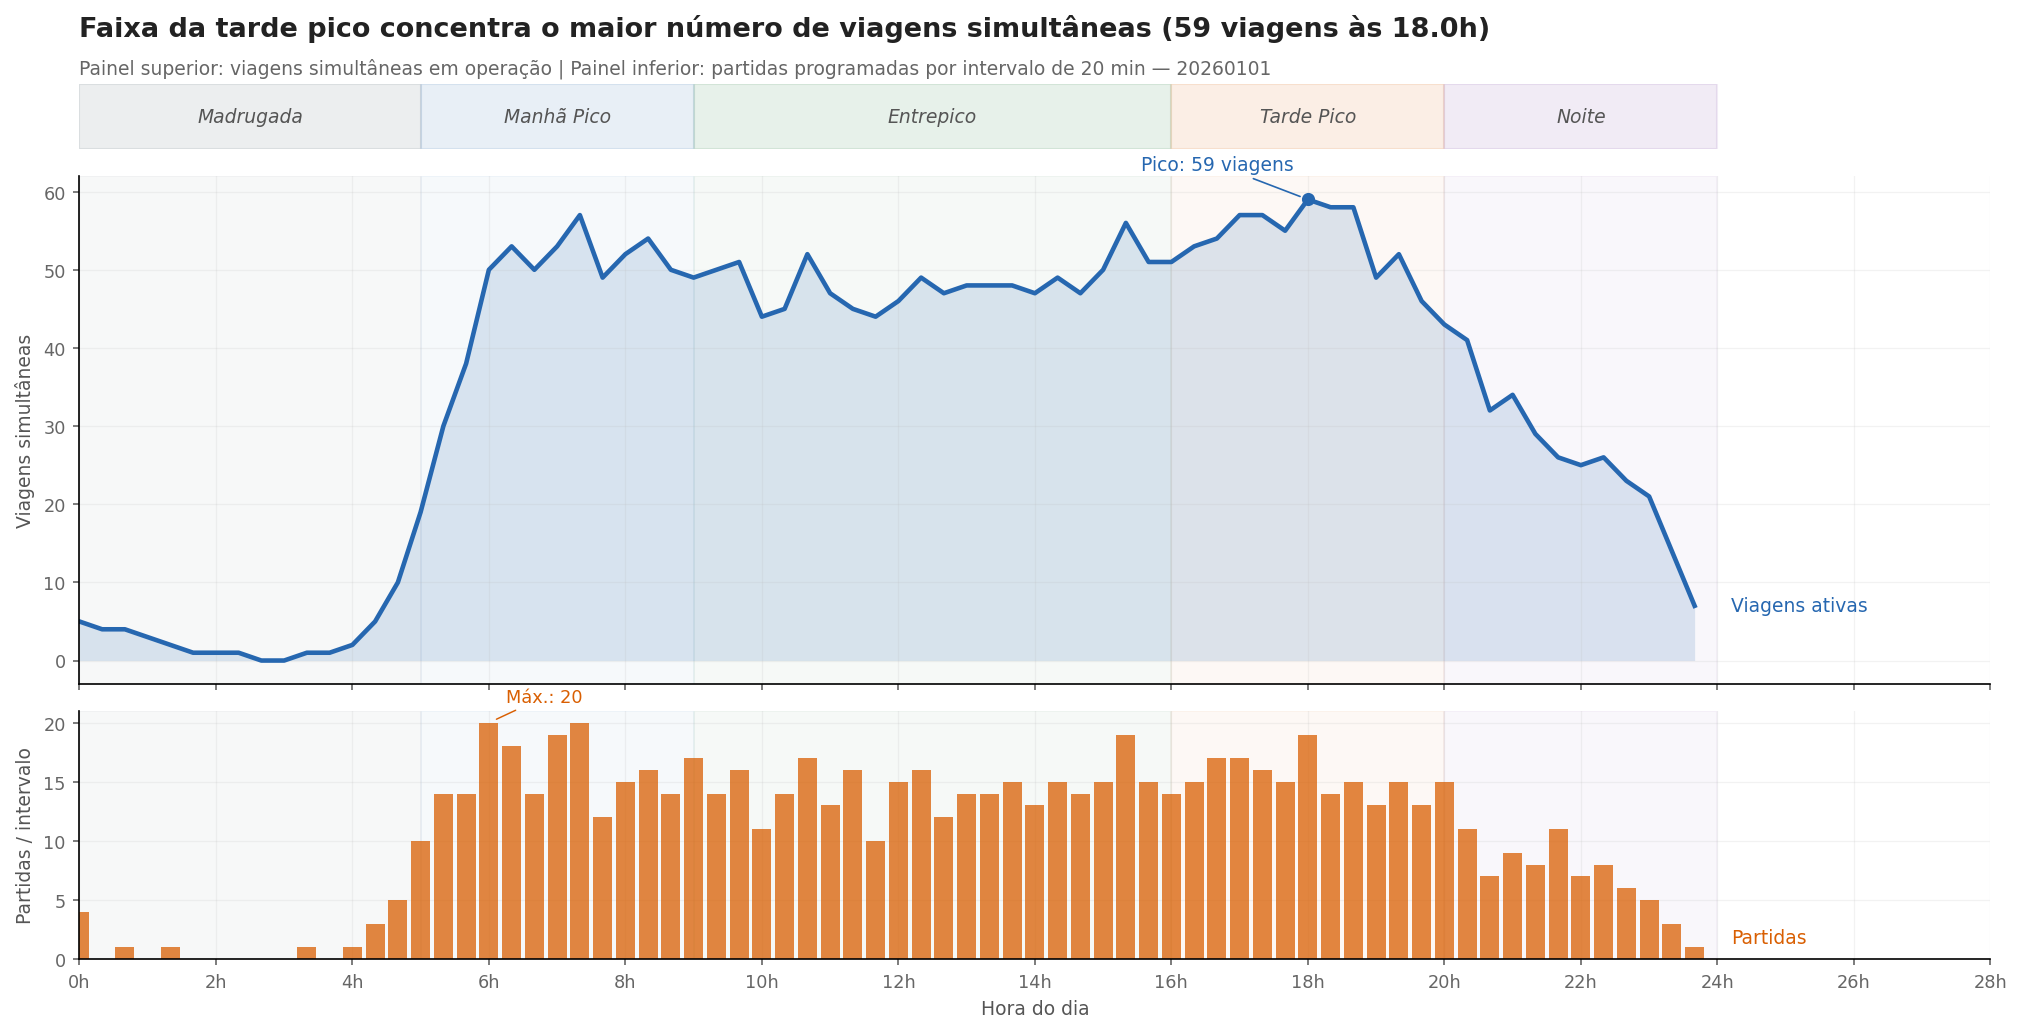

In [36]:
# ── Perfil diário de oferta ─────────────────────────────────────────
# Schwabish §2: título ativo que entrega a conclusão ao leitor.
# Schwabish §3: labels diretos nas linhas em vez de legenda separada.
# Schwabish §1: anotação de pico integrada ao gráfico, com seta.

from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker

peak_active_idx = nts["num_trips"].idxmax()
peak_start_idx  = nts["num_trip_starts"].idxmax()

peak_active_hour = nts.loc[peak_active_idx, "hour"]
peak_active_val  = nts.loc[peak_active_idx, "num_trips"]
peak_start_hour  = nts.loc[peak_start_idx, "hour"]
peak_start_val   = nts.loc[peak_start_idx, "num_trip_starts"]

# Identifica a faixa do pico para o título ativo
peak_window_name = "pico"
for name, t0, t1 in TIME_WINDOWS:
    h0 = int(t0.split(":")[0])
    h1 = int(t1.split(":")[0]) or 24
    if h0 <= peak_active_hour < h1:
        peak_window_name = name.lower()
        break

fig = plt.figure(figsize=(14, 7.2))
gs = GridSpec(nrows=3, ncols=1, height_ratios=[0.30, 2.35, 1.15],
              hspace=0.10, figure=fig)
ax_band = fig.add_subplot(gs[0])
ax1     = fig.add_subplot(gs[1], sharex=ax_band)
ax2     = fig.add_subplot(gs[2], sharex=ax_band)
fig.subplots_adjust(left=0.06, right=0.97, bottom=0.09, top=0.90)

# Título ativo (Schwabish: captura o ponto principal, não apenas descreve)
fig.text(0.06, 0.965,
         f"Faixa da {peak_window_name} concentra o maior número de viagens simultâneas"
         f" ({peak_active_val:.0f} viagens às {peak_active_hour:.1f}h)",
         ha="left", va="top", fontsize=13, fontweight="bold")
fig.text(0.06, 0.925,
         f"Painel superior: viagens simultâneas em operação | "
         f"Painel inferior: partidas programadas por intervalo de 20 min — {ANALYSIS_DATE}",
         ha="left", va="top", fontsize=9, color="#666666")

# Banda de faixas horárias
ax_band.set_xlim(0, 28)
ax_band.set_ylim(0, 1)
for i, (name, t0, t1) in enumerate(TIME_WINDOWS):
    h0 = int(t0.split(":")[0])
    h1 = int(t1.split(":")[0]) or 24
    ax_band.axvspan(h0, h1, alpha=0.10, color=WINDOW_COLORS[i], zorder=1)
    ax1.axvspan(h0, h1, alpha=0.04, color=WINDOW_COLORS[i], zorder=0)
    ax2.axvspan(h0, h1, alpha=0.04, color=WINDOW_COLORS[i], zorder=0)
    ax_band.text((h0 + h1) / 2, 0.5, name,
                 ha="center", va="center", fontsize=9,
                 color="#555555", fontstyle="italic")

for spine in ax_band.spines.values():
    spine.set_visible(False)
ax_band.set_yticks([])
ax_band.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
ax_band.grid(False)

# Painel superior – viagens ativas
ax1.fill_between(nts["hour"], nts["num_trips"],
                 color=PAL["primary"], alpha=0.15, linewidth=0, zorder=1)
ax1.plot(nts["hour"], nts["num_trips"],
         color=PAL["primary"], linewidth=2.2, zorder=2)
ax1.scatter([peak_active_hour], [peak_active_val],
            color=PAL["primary"], s=28, zorder=3)

# Anotação do pico (Schwabish §3: integrar texto ao dado)
ax1.annotate(
    f"Pico: {peak_active_val:.0f} viagens",
    xy=(peak_active_hour, peak_active_val),
    xytext=(-80, 12), textcoords="offset points",
    ha="left", va="bottom", fontsize=9, color=PAL["primary"],
    arrowprops=dict(arrowstyle="-", color=PAL["primary"],
                    lw=0.8, shrinkA=0, shrinkB=4),
)
# Label direto ao final da linha (elimina legenda — Schwabish §3)
ax1.text(24.2, nts["num_trips"].iloc[-1], "Viagens ativas",
         ha="left", va="center", fontsize=9, color=PAL["primary"], clip_on=False)
ax1.set_ylabel("Viagens simultâneas")
ax1.tick_params(axis="x", labelbottom=False)

# Painel inferior – partidas
ax2.bar(nts["hour"], nts["num_trip_starts"],
        width=0.28, color=PAL["secondary"], alpha=0.75,
        edgecolor="none", zorder=2)
ax2.annotate(
    f"Máx.: {peak_start_val:.0f}",
    xy=(peak_start_hour, peak_start_val),
    xytext=(8, 8), textcoords="offset points",
    ha="left", va="bottom", fontsize=8.5, color=PAL["secondary"],
    arrowprops=dict(arrowstyle="-", color=PAL["secondary"],
                    lw=0.7, shrinkA=0, shrinkB=4),
)
ax2.text(24.2, nts["num_trip_starts"].iloc[-1], "Partidas",
         ha="left", va="bottom", fontsize=9, color=PAL["secondary"], clip_on=False)
ax2.set_ylabel("Partidas / intervalo")
ax2.set_xlabel("Hora do dia")

for ax in (ax1, ax2):
    ax.set_xlim(0, 28)
    ax.grid(axis="y", alpha=0.18)
ax2.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax2.xaxis.set_major_formatter(lambda x, _: f"{int(x)}h")

plt.show()


In [37]:
# ── Peak metrics ─────────────────────────────────────────────────────
peak_idx = nts["num_trips"].idxmax()
peak = nts.loc[peak_idx]

total_service_km = nts["service_distance"].sum() / 1000
total_service_h = nts["service_duration"].sum()
avg_service_speed_kmh = total_service_km / max(1e-9, total_service_h)

metrics = {
    "Pico de viagens simultâneas": f"{peak['num_trips']:.0f}",
    "Horário do pico": f"{peak['hour']:.1f}h",
    "Total de partidas no dia": f"{nts['num_trip_starts'].sum():.0f}",
    "Distância total (km)": f"{total_service_km:,.0f}",
    "Duração total (h)": f"{total_service_h:,.0f}",
    "Vel. média (km/h)": f"{avg_service_speed_kmh:.1f}",
}

display(
    pd.DataFrame(list(metrics.items()), columns=["Indicador", "Valor"])
    .style.hide(axis="index").set_caption("Métricas de pico")
)


Indicador,Valor
Pico de viagens simultâneas,59
Horário do pico,18.0h
Total de partidas no dia,781
Distância total (km),"11,788"
Duração total (h),607
Vel. média (km/h),19.4


---
## 3 — Stop-level Analysis

### 3.1 Stop statistics & headway distribution

In [38]:
# ── Compute stop stats ───────────────────────────────────────────────
stop_stats = feed.compute_stop_stats(
    [ANALYSIS_DATE],
    headway_start_time=HEADWAY_START,
    headway_end_time=HEADWAY_END,
    split_directions=False,
)

# Merge geometry
stops_gdf = (
    feed.stops[["stop_id", "stop_name", "stop_lat", "stop_lon"]]
    .merge(stop_stats, on="stop_id", how="inner")
    .pipe(lambda df: gpd.GeoDataFrame(
        df, crs=4326,
        geometry=gpd.points_from_xy(df.stop_lon, df.stop_lat),
    ))
)

# Frequency per hour
stops_gdf["frequency_per_hour"] = np.where(
    stops_gdf["mean_headway"] > 0,
    60 / stops_gdf["mean_headway"],
    0,
)

print(f"Stops with stats: {len(stops_gdf)}")
display(
    stops_gdf
    .nlargest(10, "num_trips")
    [["stop_name", "num_trips", "mean_headway", "frequency_per_hour"]]
    .style.format({"mean_headway": "{:.1f}", "frequency_per_hour": "{:.1f}"})
    .set_caption("Top 10 paradas por viagens")
    .hide(axis="index")
)

Stops with stats: 830


stop_name,num_trips,mean_headway,frequency_per_hour
"Avenida Júlia Kubitschek, 20",675.000000,1.6,38.2
Avenida Júlia Kubitsheck 587,634.000000,1.7,35.8
Avenida Júlia Kubitschek 562,624.000000,1.7,35.2
"Av. Júlia Kubitscheck, 125",601.000000,1.8,33.8
"Rua Silva Jardim, 9",601.000000,1.8,33.8
"Avenida Júlia Kubitschek, 26",593.000000,1.8,33.2
"Avenida Teixeira e Souza, 2031",584.000000,1.8,32.7
"Avenida Teixeira e Souza, 1600",584.000000,1.8,32.7
Avenida Teixeira e Souza 202,584.000000,1.8,32.7
Avenida Teixeira e Souza 2,584.000000,1.8,32.7


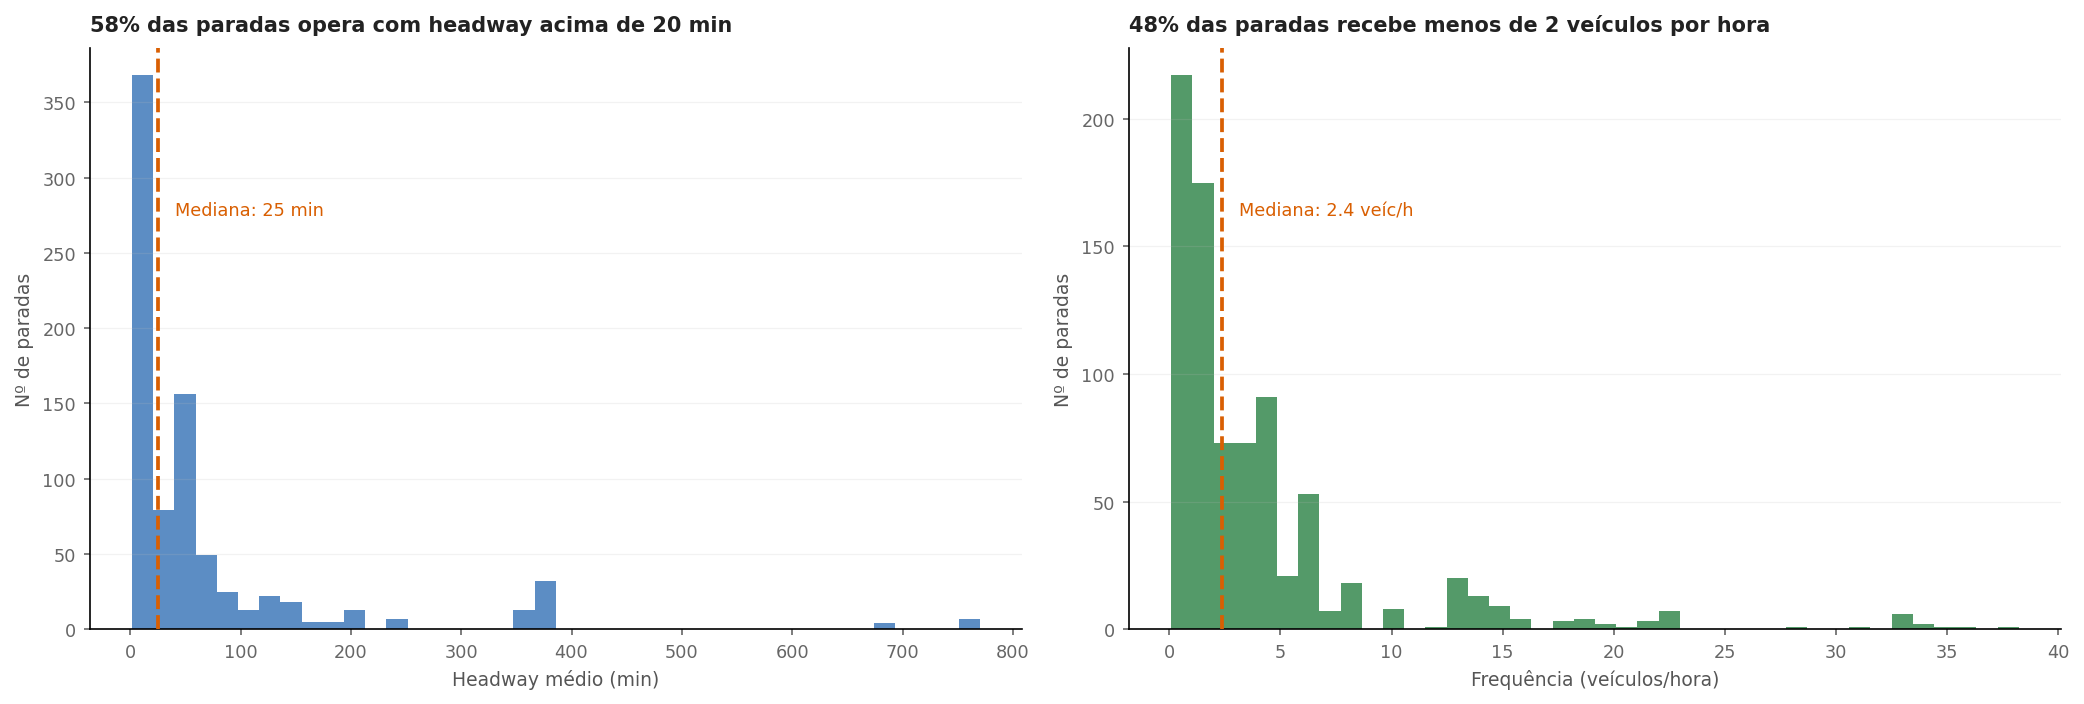

In [39]:
# ── Distribuição de headways e frequências ──────────────────────────
# Schwabish §3: título ativo com a conclusão principal.
# Schwabish §3: mediana anotada diretamente no gráfico, sem legenda.
# Schwabish §2: sem bordas em barras; grade leve apenas no eixo Y.

hw   = stops_gdf["mean_headway"].dropna()
hw   = hw[hw > 0]
freq = stops_gdf["frequency_per_hour"].dropna()
freq = freq[freq > 0]

med_hw   = hw.median()
med_freq = freq.median()
pct_above_20min = (hw > 20).mean() * 100
pct_below_2vh   = (freq < 2).mean() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))

# ── Histograma de headway ────────────────────────────────────────────
ax1.hist(hw, bins=40, color=PAL["primary"], edgecolor="none", alpha=0.75)
ax1.axvline(med_hw, color=PAL["secondary"], linewidth=1.8, linestyle="--", zorder=5)

# Anotação direta da mediana (Schwabish §3 – sem legenda separada)
ylim1 = ax1.get_ylim()
ax1.annotate(
    f"Mediana: {med_hw:.0f} min",
    xy=(med_hw, (ylim1[1] - ylim1[0]) * 0.72 + ylim1[0]),
    xytext=(8, 0), textcoords="offset points",
    ha="left", va="center", fontsize=8.5, color=PAL["secondary"],
)
ax1.set_xlabel("Headway médio (min)")
ax1.set_ylabel("Nº de paradas")
# Título ativo: entrega a conclusão, não apenas descreve (Schwabish §3)
ax1.set_title(
    f"{pct_above_20min:.0f}% das paradas opera com headway acima de 20 min",
    fontsize=10, fontweight="bold", loc="left", pad=8
)
ax1.grid(axis="y", alpha=0.18)
ax1.grid(axis="x", alpha=0)

# ── Histograma de frequência ─────────────────────────────────────────
ax2.hist(freq, bins=40, color=PAL["accent"], edgecolor="none", alpha=0.75)
ax2.axvline(med_freq, color=PAL["secondary"], linewidth=1.8, linestyle="--", zorder=5)

ylim2 = ax2.get_ylim()
ax2.annotate(
    f"Mediana: {med_freq:.1f} veíc/h",
    xy=(med_freq, (ylim2[1] - ylim2[0]) * 0.72 + ylim2[0]),
    xytext=(8, 0), textcoords="offset points",
    ha="left", va="center", fontsize=8.5, color=PAL["secondary"],
)
ax2.set_xlabel("Frequência (veículos/hora)")
ax2.set_ylabel("Nº de paradas")
ax2.set_title(
    f"{pct_below_2vh:.0f}% das paradas recebe menos de 2 veículos por hora",
    fontsize=10, fontweight="bold", loc="left", pad=8
)
ax2.grid(axis="y", alpha=0.18)
ax2.grid(axis="x", alpha=0)

plt.tight_layout()
plt.show()


### 3.2 Frequency map

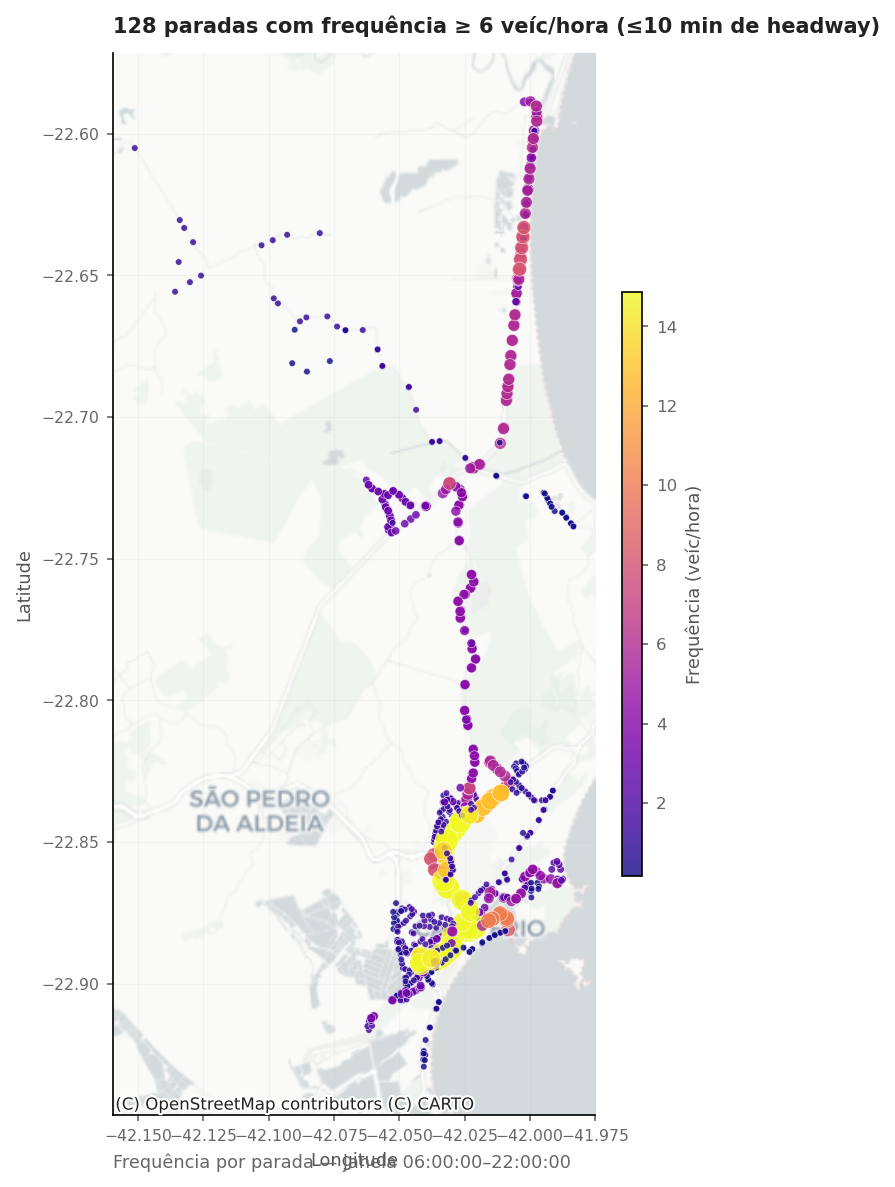

In [40]:
# ── Mapa de frequência por parada (figura estática) ─────────────────
# Substituição de plotly.scatter_mapbox por matplotlib + geopandas.
# Schwabish §1: dados em foco; fundo neutro.
# Schwabish §5: todas as paradas sem dados relevantes em cinza claro.
#
# NOTA: sem basemap de tiles (sem conexão de rede).
# Para adicionar basemap, instale contextily e descomente as linhas
# marcadas com "# ctx".
#
import contextily as ctx

gdf_freq = stops_gdf.loc[stops_gdf["frequency_per_hour"] > 0].copy()

# Razão de aspecto correta para a latitude local
lat_mean = gdf_freq["stop_lat"].mean()
asp = 1.0 / np.cos(np.radians(lat_mean))

fig, ax = plt.subplots(figsize=(9, 8))
fig.patch.set_facecolor("white")

# Camada de contexto: todas as paradas em cinza claro (Schwabish §5)
ax.scatter(
    feed.stops["stop_lon"], feed.stops["stop_lat"],
    c=PAL["light_gray"], s=5, linewidths=0, alpha=0.55, zorder=1,
    rasterized=True,
)

# Dados: tamanho e cor proporcionais à frequência
freq_vals = gdf_freq["frequency_per_hour"].values
sc = ax.scatter(
    gdf_freq["stop_lon"], gdf_freq["stop_lat"],
    c=freq_vals,
    s=np.clip(freq_vals * 5.5, 10, 140),
    cmap="plasma",
    norm=mcolors.Normalize(vmin=np.percentile(freq_vals, 5),
                           vmax=np.percentile(freq_vals, 95)),
    alpha=0.80, linewidth=0.3, edgecolors="white",
    zorder=2, rasterized=True,
)

# Colorbar discreta (Schwabish §2: elementos auxiliares discretos)
cbar = fig.colorbar(sc, ax=ax, shrink=0.55, pad=0.02, aspect=28)
cbar.set_label("Frequência (veíc/hora)", fontsize=8.5)
cbar.ax.tick_params(labelsize=8)

# Título ativo (Schwabish §3)
n_high = int((freq_vals >= 6).sum())
ax.set_title(
    f"{n_high} paradas com frequência ≥ 6 veíc/hora (≤10 min de headway)",
    fontsize=10, fontweight="bold", loc="left", pad=10
)
ax.text(0.0, -0.05,
        f"Frequência por parada — janela {HEADWAY_START}–{HEADWAY_END}",
        transform=ax.transAxes, fontsize=8.5, color="#666666")

# Ajustes cartográficos
ax.set_aspect(asp)
ax.set_xlabel("Longitude", fontsize=8.5)
ax.set_ylabel("Latitude", fontsize=8.5)
ax.tick_params(labelsize=7.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.12, linewidth=0.5)

ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron)

plt.tight_layout()
plt.show()


### 3.3 Headway map

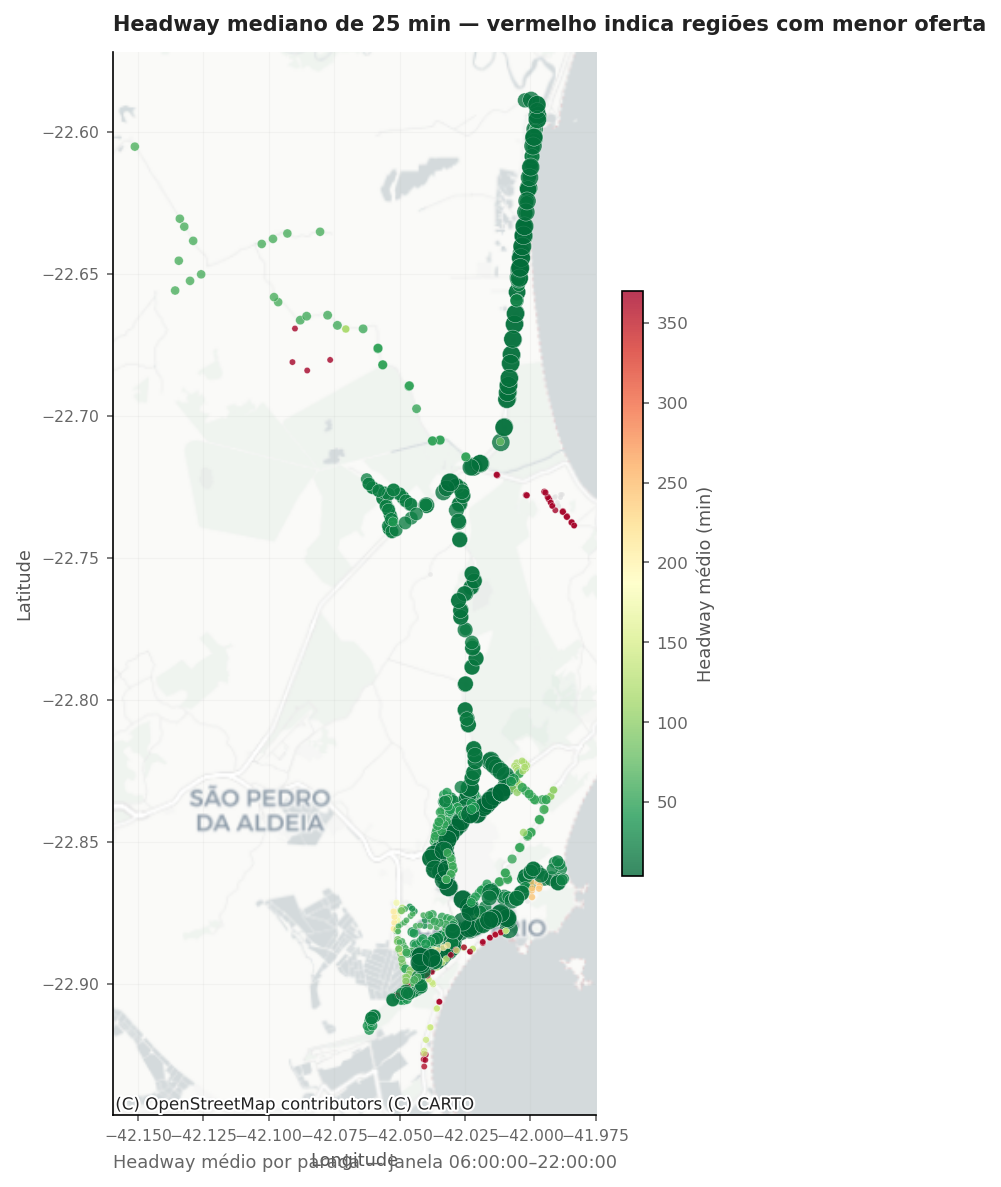

In [41]:
# ── Mapa de headway médio por parada (figura estática) ──────────────
# Schwabish §5: contexto em cinza; dado principal em escala de cor.
# Escala RdYlGn_r: vermelho = headway longo (pior), verde = curto (melhor).

gdf_hw = stops_gdf.loc[stops_gdf["mean_headway"] > 0].copy()
lat_mean = gdf_hw["stop_lat"].mean()
asp = 1.0 / np.cos(np.radians(lat_mean))

fig, ax = plt.subplots(figsize=(9, 8))
fig.patch.set_facecolor("white")

# Contexto: todas as paradas em cinza
ax.scatter(
    feed.stops["stop_lon"], feed.stops["stop_lat"],
    c=PAL["light_gray"], s=5, linewidth=0, alpha=0.55, zorder=1,
    rasterized=True,
)

# Headway: cor RdYlGn_r (vermelhos = headway longo = pior serviço)
hw_vals = gdf_hw["mean_headway"].values
sc = ax.scatter(
    gdf_hw["stop_lon"], gdf_hw["stop_lat"],
    c=hw_vals,
    s=np.clip(gdf_hw["num_trips"].values * 0.6 + 8, 8, 80),
    cmap="RdYlGn_r",
    norm=mcolors.Normalize(vmin=np.percentile(hw_vals, 5),
                           vmax=np.percentile(hw_vals, 95)),
    alpha=0.78, linewidth=0.2, edgecolors="white",
    zorder=2, rasterized=True,
)

cbar = fig.colorbar(sc, ax=ax, shrink=0.55, pad=0.02, aspect=28)
cbar.set_label("Headway médio (min)", fontsize=8.5)
cbar.ax.tick_params(labelsize=8)

# Título ativo
med_hw_map = np.median(hw_vals)
ax.set_title(
    f"Headway mediano de {med_hw_map:.0f} min — vermelho indica regiões com menor oferta",
    fontsize=10, fontweight="bold", loc="left", pad=10
)
ax.text(0.0, -0.05,
        f"Headway médio por parada — janela {HEADWAY_START}–{HEADWAY_END}",
        transform=ax.transAxes, fontsize=8.5, color="#666666")

ax.set_aspect(asp)
ax.set_xlabel("Longitude", fontsize=8.5)
ax.set_ylabel("Latitude", fontsize=8.5)
ax.tick_params(labelsize=7.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.12, linewidth=0.5)

ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron)

plt.tight_layout()
plt.show()


---
## 4 — Route Corridors

Segments with the greatest concentration of overlapping routes.
Built by snapping routes to a common network of inter-stop edges and
counting how many route-directions traverse each segment.

In [42]:
# ── Build route corridor concentration ───────────────────────────────
# Mantém duas leituras:
# 1) segmento direcional stop->stop
# 2) corredor agregado, colapsando ida/volta no mesmo par de paradas

st = feed.stop_times.copy()
trips = feed.trips[["trip_id", "route_id", "direction_id"]].copy()
trips["direction_id"] = trips["direction_id"].fillna(-1).astype(int)

# Active trips on analysis date
activity = feed.compute_trip_activity([ANALYSIS_DATE])
active_ids = set(activity.loc[activity[ANALYSIS_DATE] > 0, "trip_id"])
st = st.loc[st["trip_id"].isin(active_ids)].copy()

# Merge route info
st = st.merge(trips, on="trip_id", how="inner")

# Create stop-pair segments
st = st.sort_values(["trip_id", "stop_sequence"])
st["next_stop_id"] = st.groupby("trip_id")["stop_id"].shift(-1)
segments = st.dropna(subset=["next_stop_id"]).copy()

segments["route_dir_key"] = (
    segments["route_id"].astype(str) + "::" + segments["direction_id"].astype(str)
)

# Directed segment key: A -> B
segments["seg_key_dir"] = list(zip(segments["stop_id"], segments["next_stop_id"]))

# Corridor key: colapsa A->B e B->A no mesmo par não ordenado
stop_a_str = segments["stop_id"].astype(str).to_numpy()
stop_b_str = segments["next_stop_id"].astype(str).to_numpy()
segments["seg_a"] = np.where(stop_a_str <= stop_b_str, segments["stop_id"], segments["next_stop_id"])
segments["seg_b"] = np.where(stop_a_str <= stop_b_str, segments["next_stop_id"], segments["stop_id"])
segments["seg_key_corridor"] = list(zip(segments["seg_a"], segments["seg_b"]))

# Direcional: útil para auditoria e análises futuras
seg_dir = (
    segments
    .groupby("seg_key_dir", as_index=False)
    .agg(
        n_routes=("route_id", "nunique"),
        n_route_dirs=("route_dir_key", "nunique"),
        n_trips=("trip_id", "nunique"),
        stop_a=("stop_id", "first"),
        stop_b=("next_stop_id", "first"),
    )
)

# Corredor agregado: leitura sintética do eixo de sobreposição
seg_corridor = (
    segments
    .groupby("seg_key_corridor", as_index=False)
    .agg(
        n_routes=("route_id", "nunique"),
        n_route_dirs=("route_dir_key", "nunique"),
        n_trips=("trip_id", "nunique"),
        stop_a=("seg_a", "first"),
        stop_b=("seg_b", "first"),
    )
)

print(f"Segmentos direcionais: {len(seg_dir)}")
print(f"Corredores agregados: {len(seg_corridor)}")
print(f"Máx. rotas por corredor: {seg_corridor['n_routes'].max()}")
print(f"Máx. rota-sentidos por corredor: {seg_corridor['n_route_dirs'].max()}")
print(f"Máx. viagens por corredor: {seg_corridor['n_trips'].max()}")


Segmentos direcionais: 1545
Corredores agregados: 1004
Máx. rotas por corredor: 21
Máx. rota-sentidos por corredor: 38
Máx. viagens por corredor: 624


In [43]:
# ── Build segment geometries ─────────────────────────────────────────
stop_xy = feed.stops.set_index("stop_id")[["stop_lon", "stop_lat"]]
stop_pts = {
    stop_id: sg.Point(row["stop_lon"], row["stop_lat"])
    for stop_id, row in stop_xy.iterrows()
}

seg_corridor["geometry"] = seg_corridor.apply(
    lambda r: sg.LineString([
        stop_pts.get(r["stop_a"], sg.Point(0, 0)),
        stop_pts.get(r["stop_b"], sg.Point(0, 0)),
    ]),
    axis=1,
)

seg_gdf = gpd.GeoDataFrame(seg_corridor, crs=4326, geometry="geometry")
seg_gdf = seg_gdf.loc[~seg_gdf.geometry.is_empty & seg_gdf.geometry.is_valid].copy()


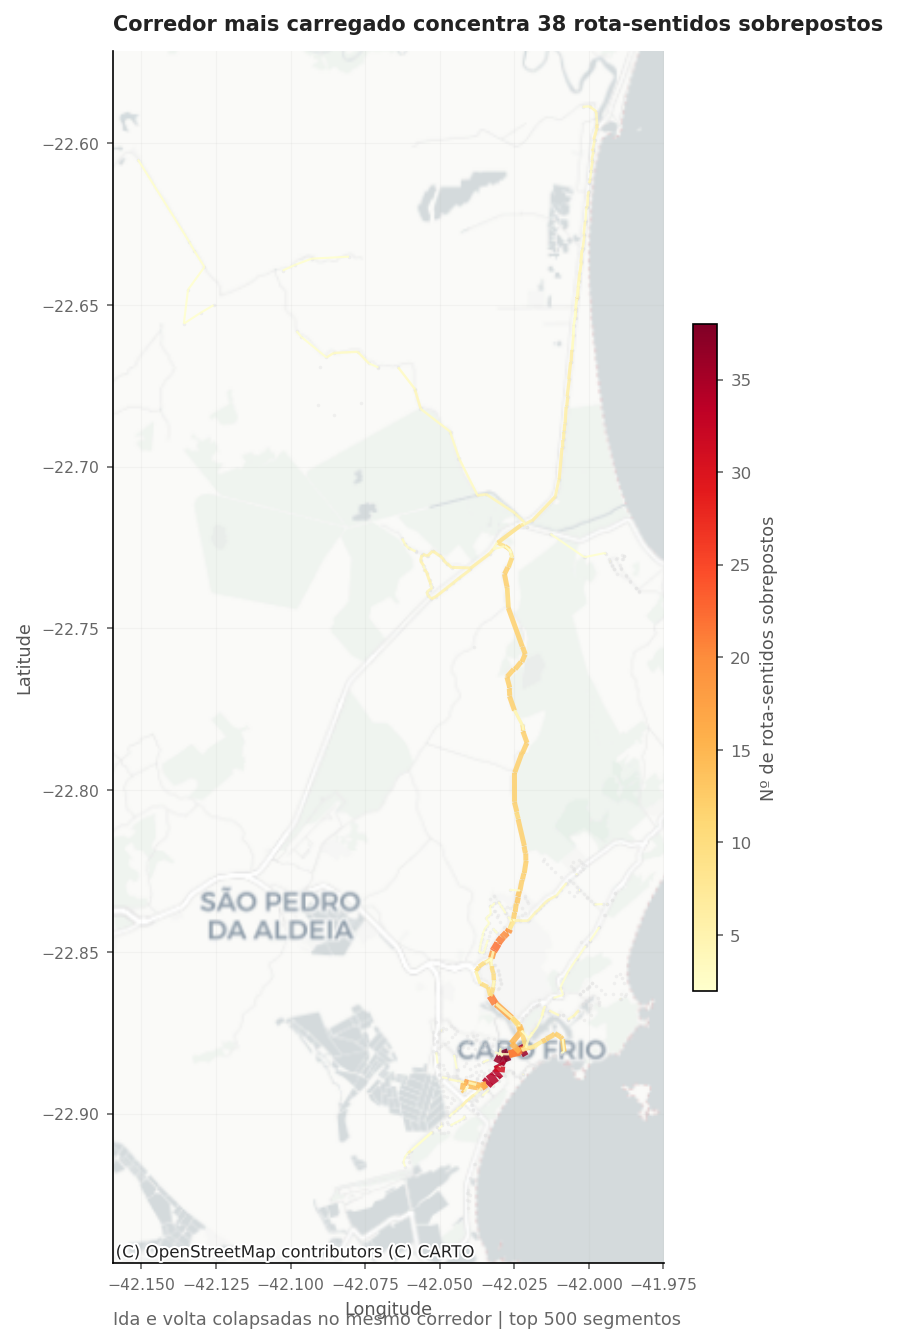

In [57]:
# ── Mapa de corredores (LineCollection estática) ────────────────────
# Substitui Plotly por matplotlib.collections.LineCollection:
#   – eficiente: uma única coleção vetorial em vez de N traces
#   – estático: adequado para relatório PDF/Word
#   – corrige: matplotlib ≥3.7 deprecia cm.get_cmap()/plt.get_cmap() → usar
#
# Schwabish §5: linhas de baixa concentração em cinza; destacam-se
#               apenas os corredores mais sobrepostos (paleta YlOrRd).

top_segs = seg_gdf.nlargest(500, "n_route_dirs").copy()
if top_segs.crs is not None and top_segs.crs.to_epsg() != 4326:
    top_segs = top_segs.to_crs(4326)

lat_mean = feed.stops["stop_lat"].mean()
asp = 1.0 / np.cos(np.radians(lat_mean))

# Prepara linhas e valores para LineCollection
lines, values = [], []
for _, row in top_segs.iterrows():
    geom = row.geometry
    if geom is None or geom.is_empty:
        continue
    parts = list(geom.geoms) if geom.geom_type == "MultiLineString" else [geom]
    for part in parts:
        lines.append(list(zip(*part.xy)))
        values.append(row["n_route_dirs"])

values_arr = np.array(values, dtype=float)
norm = mcolors.Normalize(vmin=values_arr.min(), vmax=values_arr.max())
cmap = matplotlib.colormaps["YlOrRd"]   # API moderna: matplotlib.colormaps[] (mpl ≥3.7)

# Espessura proporcional ao número de rota-sentidos (1.0–6.0 px)
widths = 1.0 + 5.0 * norm(values_arr)

fig, ax = plt.subplots(figsize=(10, 9))
fig.patch.set_facecolor("white")

# Contexto: todas as paradas em cinza claro
ax.scatter(
    feed.stops["stop_lon"], feed.stops["stop_lat"],
    c=PAL["light_gray"], s=3, linewidths=0, alpha=0.40, zorder=1,
    rasterized=True,
)

# LineCollection
lc = LineCollection(lines, cmap=cmap, norm=norm,
                    linewidths=widths, alpha=0.85, zorder=2)
lc.set_array(values_arr)
ax.add_collection(lc)
ax.autoscale_view()

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.02, aspect=28)
cbar.set_label("Nº de rota-sentidos sobrepostos", fontsize=8.5)
cbar.ax.tick_params(labelsize=8)

# Título ativo
max_rdir = int(values_arr.max())
ax.set_title(
    f"Corredor mais carregado concentra {max_rdir} rota-sentidos sobrepostos",
    fontsize=10, fontweight="bold", loc="left", pad=10
)
ax.text(0.0, -0.05,
        "Ida e volta colapsadas no mesmo corredor | top 500 segmentos",
        transform=ax.transAxes, fontsize=8.5, color="#666666")

ax.set_aspect(asp)
ax.set_xlabel("Longitude", fontsize=8.5)
ax.set_ylabel("Latitude", fontsize=8.5)
ax.tick_params(labelsize=7.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.12, linewidth=0.5)

ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron)

plt.tight_layout()
plt.show()


In [45]:
# ── Alternativa: mapa interativo com geopandas.explore ─────────────
# (descomente se quiser explorar o mapa interativamente no Jupyter;
#  não adequado para exportação estática de relatório)

# top_segs.explore(
#     column="n_routes",
#     cmap="YlOrRd",
#     style_kwds={"weight": top_segs["n_routes"] / top_segs["n_routes"].max() * 8 + 1},
#     tooltip=["stop_a", "stop_b", "n_routes", "n_trips"],
# )


---
## 5 — Service Kilometres (VKT)

Daily vehicle-kilometres traveled for all active routes.

In [46]:
# ── Compute trip stats ───────────────────────────────────────────────
#
# NOTA DE UNIDADES (importante para portabilidade):
# gtfs_kit.compute_trip_stats() usa shape_dist_traveled da coluna
# stop_times para calcular distância e velocidade.
#
# Caso A — feed COM shape_dist_traveled em metros (típico em feeds
#           brasileiros e europeus): 'distance' estará em metros e
#           'speed' em m/h. As divisões por 1 000 abaixo estão corretas.
#
# Caso B — feed SEM shape_dist_traveled (gtfs_kit calculou via
#           append_dist_to_stop_times com dist_units="km"): 'distance'
#           já em km e 'speed' em km/h. Remova as divisões por 1 000.
#
# Verifique com: feed.stop_times["shape_dist_traveled"].describe()
# Se a mediana for da ordem de 1 000–50 000 → metros (Caso A).
# Se a mediana for da ordem de 1–50 → km (Caso B).

trip_stats = feed.compute_trip_stats()

# Filtra viagens ativas na data de análise
trip_stats = trip_stats.loc[trip_stats["trip_id"].isin(active_ids)].copy()

# Conversão de unidades (ajuste DIST_FACTOR se necessário — ver nota acima)
DIST_FACTOR = 1_000   # 1000 para feeds com shape_dist_traveled em metros
trip_stats["distance_km"] = trip_stats["distance"] / DIST_FACTOR
trip_stats["speed_kmh"]   = trip_stats["speed"]    / DIST_FACTOR

total_km       = trip_stats["distance_km"].sum()
total_duration = trip_stats["duration"].sum()   # horas
total_trips    = len(trip_stats)

print(f"Viagens ativas : {total_trips}")
print(f"VKT total      : {total_km:,.0f} km")
print(f"Horas-veículo  : {total_duration:,.0f} h")
print(f"Vel. média      : {total_km / max(1e-9, total_duration):.1f} km/h")


Viagens ativas : 781
VKT total      : 11,788 km
Horas-veículo  : 607 h
Vel. média      : 19.4 km/h


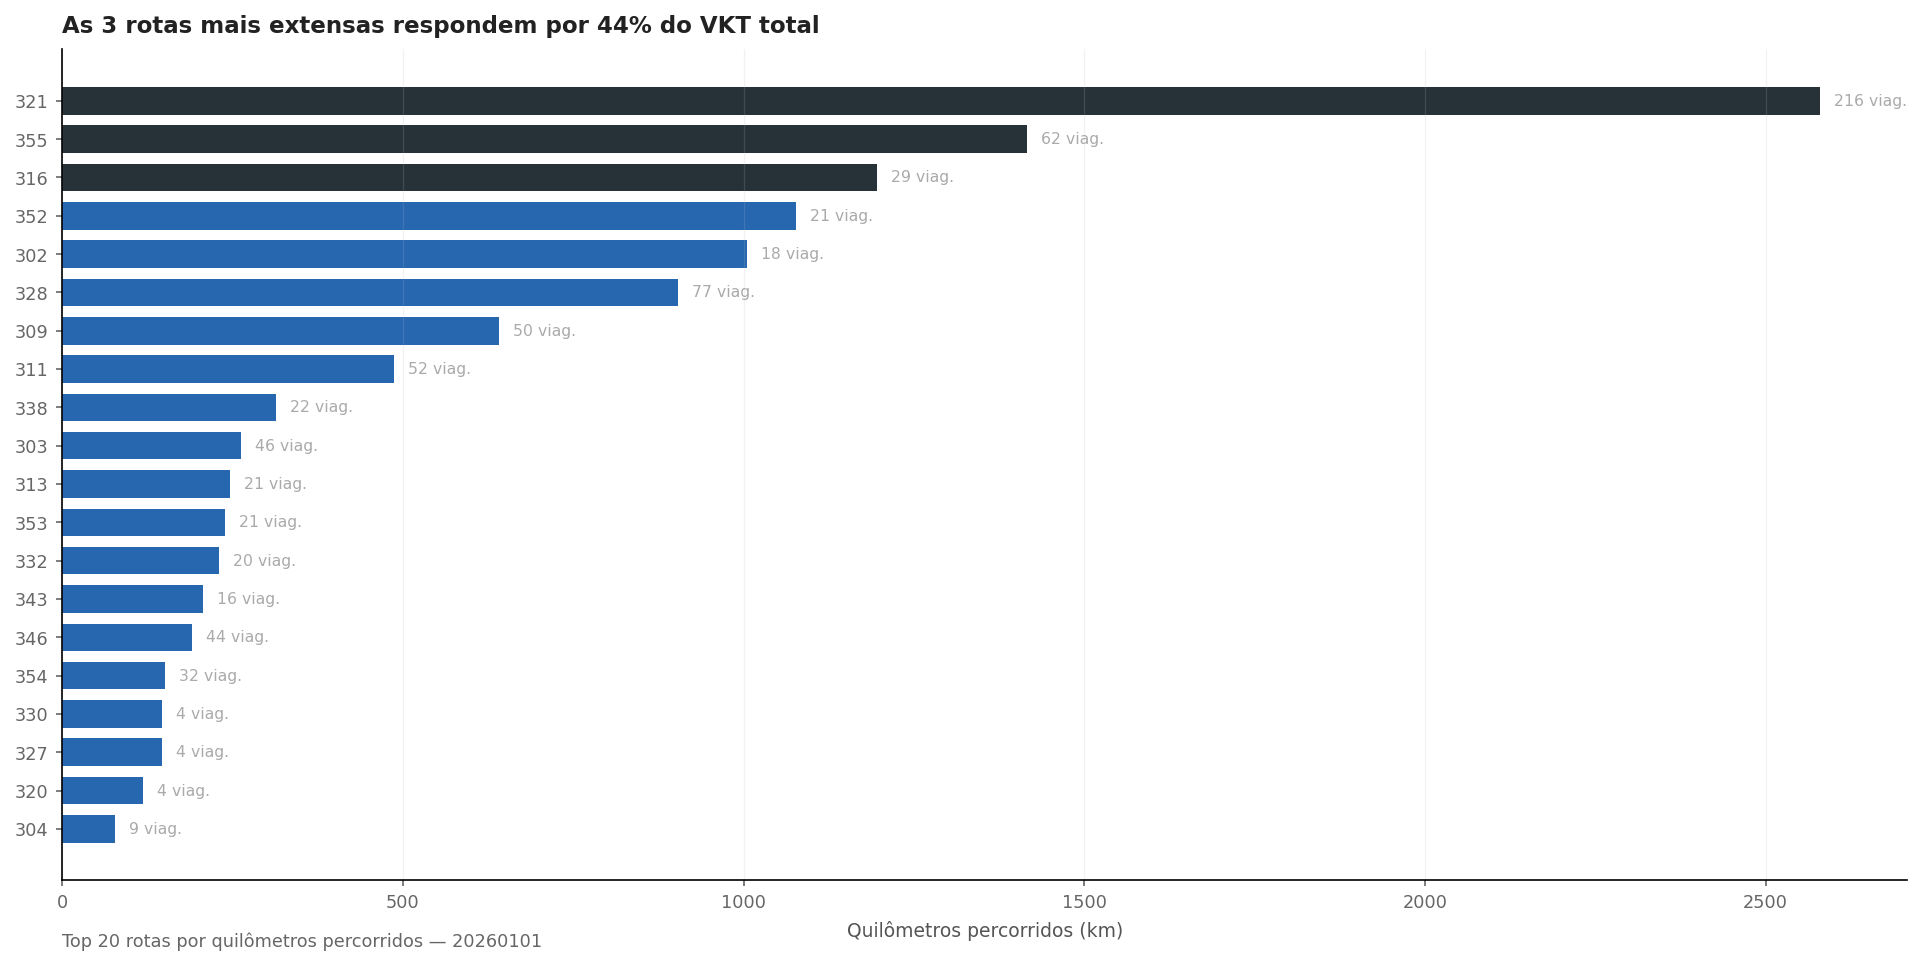

In [47]:
# ── VKT por rota — top 20 ────────────────────────────────────────────
# Schwabish §3: título ativo que entrega insight.
# Schwabish §2: label de viagens em cinza discreto, sem cluttering.
# Barras horizontais facilitam leitura de rótulos de categoria.

route_km = (
    trip_stats
    .merge(feed.trips[["trip_id", "route_id"]])
    .merge(feed.routes[["route_id", "route_short_name"]])
    .groupby("route_short_name")
    .agg(
        vkt=("distance_km", "sum"),
        trips=("trip_id", "count"),
        avg_dist=("distance_km", "mean"),
        avg_speed=("speed_kmh", "mean"),
    )
    .sort_values("vkt", ascending=False)
)

top20 = route_km.head(20)
top3_share = top20["vkt"].head(3).sum() / total_km * 100

fig, ax = plt.subplots(figsize=(13, 6.5))

# Barras em azul; destaque para top-3 em tom mais escuro (Schwabish §1)
colors = [PAL["dark"] if i < 3 else PAL["primary"] for i in range(len(top20))]
ax.barh(range(len(top20)), top20["vkt"],
        color=colors, edgecolor="none", height=0.72)

# Labels de viagens em cinza discreto (Schwabish §2: não compete com dado principal)
max_vkt = top20["vkt"].max()
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(row["vkt"] + max_vkt * 0.008, i,
            f'{row["trips"]:.0f} viag.', va="center",
            fontsize=7.5, color=PAL["gray"])

ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel("Quilômetros percorridos (km)")
ax.grid(axis="x", alpha=0.18)
ax.grid(axis="y", alpha=0)

# Título ativo (Schwabish §3)
ax.set_title(
    f"As 3 rotas mais extensas respondem por {top3_share:.0f}% do VKT total",
    fontsize=11, fontweight="bold", loc="left", pad=8
)
ax.text(0, -0.08, f"Top 20 rotas por quilômetros percorridos — {ANALYSIS_DATE}",
        transform=ax.transAxes, fontsize=8.5, color="#666666")

plt.tight_layout()
plt.show()


faixa_horaria,vkt_km,departures,avg_simultaneous_trips,window_hours,vkt_km_h,departures_h
Madrugada,351.8,16,2.7,5.0,70.4,3.2
Manhã Pico,"2,763.4",186,46.2,4.0,690.8,46.5
Entrepico,"4,319.6",305,48.2,7.0,617.1,43.6
Tarde Pico,"2,844.6",183,54.1,4.0,711.2,45.8
Noite,"1,508.8",91,26.8,4.0,377.2,22.8


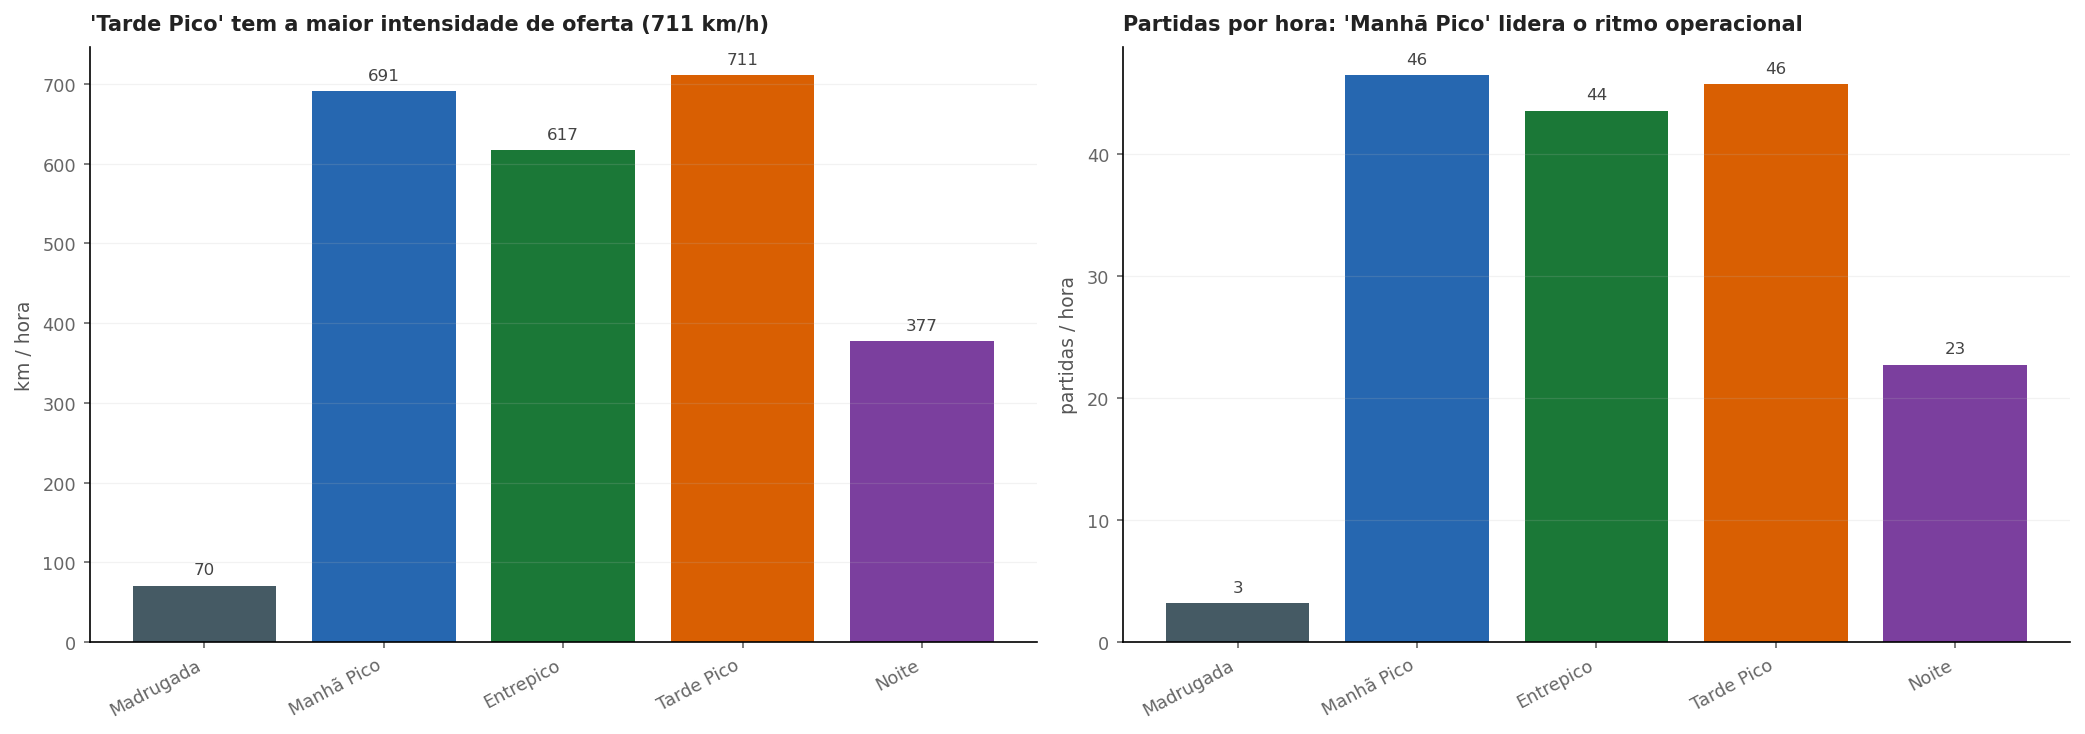

In [48]:
# ── Oferta por faixa horária: intensidades ───────────────────────────
# Schwabish §2: anotação simplificada (apenas a intensidade por hora,
#               não dois valores empilhados que geram cluttering).
# Schwabish §3: título ativo identifica a faixa de maior oferta.

def hhmmss_to_hours(s):
    hh, mm, ss = map(int, s.split(":"))
    return hh + mm / 60 + ss / 3600

def hour_in_day(h):
    return h % 24

def assign_window(hour):
    h = hour_in_day(hour)
    for name, t0, t1 in TIME_WINDOWS:
        h0 = hhmmss_to_hours(t0)
        h1 = hhmmss_to_hours(t1)
        if h0 <= h < h1:
            return name
    return "Outro"

window_order = [w[0] for w in TIME_WINDOWS]
window_hours = pd.Series(
    {name: hhmmss_to_hours(t1) - hhmmss_to_hours(t0)
     for name, t0, t1 in TIME_WINDOWS},
    name="window_hours",
)

trip_stats["start_hour"] = trip_stats["start_time"].apply(hhmmss_to_hours)
trip_stats["window"]     = trip_stats["start_hour"].apply(assign_window)

nts_window         = nts.copy()
nts_window["window"] = nts_window["hour"].apply(assign_window)

window_summary = (
    nts_window
    .groupby("window")
    .agg(
        vkt_km=("service_distance", lambda s: s.sum() / DIST_FACTOR),
        departures=("num_trip_starts", "sum"),
        avg_simultaneous_trips=("num_trips", "mean"),
    )
    .reindex(window_order)
    .fillna(0)
)
window_summary = window_summary.join(window_hours)
window_summary["vkt_km_h"]    = window_summary["vkt_km"]    / window_summary["window_hours"]
window_summary["departures_h"] = window_summary["departures"] / window_summary["window_hours"]

display(
    window_summary
    .reset_index(names="faixa_horaria")
    .style
    .format({
        "vkt_km": "{:,.1f}",
        "departures": "{:,.0f}",
        "avg_simultaneous_trips": "{:.1f}",
        "window_hours": "{:.1f}",
        "vkt_km_h": "{:,.1f}",
        "departures_h": "{:.1f}",
    })
    .set_caption("Oferta por faixa horária — totais e intensidades")
    .hide(axis="index")
)

# Título ativo: identifica a faixa de maior intensidade
peak_w_intensity = window_summary["vkt_km_h"].idxmax()
peak_w_val       = window_summary.loc[peak_w_intensity, "vkt_km_h"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── VKT por hora ─────────────────────────────────────────────────────
vals1 = window_summary["vkt_km_h"].values
bars1 = ax1.bar(range(len(window_summary)), vals1,
                color=WINDOW_COLORS, edgecolor="none")

# Anotação: apenas o valor de intensidade (Schwabish §2 – sem dupla info)
for i, v in enumerate(vals1):
    ax1.text(i, v + max(vals1) * 0.015, f"{v:.0f}",
             ha="center", va="bottom", fontsize=8, color="#444")

ax1.set_xticks(range(len(window_summary)))
ax1.set_xticklabels(window_summary.index, rotation=28, ha="right")
ax1.set_ylabel("km / hora")
ax1.grid(axis="y", alpha=0.18)
ax1.grid(axis="x", alpha=0)
ax1.set_title(
    f"'{peak_w_intensity}' tem a maior intensidade de oferta ({peak_w_val:.0f} km/h)",
    fontsize=10, fontweight="bold", loc="left", pad=8
)

# ── Partidas por hora ─────────────────────────────────────────────────
vals2 = window_summary["departures_h"].values
ax2.bar(range(len(window_summary)), vals2,
        color=WINDOW_COLORS, edgecolor="none")

for i, v in enumerate(vals2):
    ax2.text(i, v + max(vals2) * 0.015, f"{v:.0f}",
             ha="center", va="bottom", fontsize=8, color="#444")

ax2.set_xticks(range(len(window_summary)))
ax2.set_xticklabels(window_summary.index, rotation=28, ha="right")
ax2.set_ylabel("partidas / hora")
ax2.grid(axis="y", alpha=0.18)
ax2.grid(axis="x", alpha=0)
peak_w_dep = window_summary["departures_h"].idxmax()
ax2.set_title(
    f"Partidas por hora: '{peak_w_dep}' lidera o ritmo operacional",
    fontsize=10, fontweight="bold", loc="left", pad=8
)

plt.tight_layout()
plt.show()


---
## 6 — Trip Summary Table

Comprehensive overview: trips, distances, and durations broken down by
route, time window, and direction.

In [49]:
# ── Route-level summary ──────────────────────────────────────────────
route_summary = (
    trip_stats
    .merge(feed.trips[["trip_id", "route_id", "direction_id"]])
    .merge(feed.routes[["route_id", "route_short_name", "route_long_name"]])
    .groupby(["route_short_name", "route_long_name"])
    .agg(
        viagens=("trip_id", "count"),
        km_total=("distance_km", "sum"),
        km_medio=("distance_km", "mean"),
        duracao_media_min=("duration", lambda x: x.mean() * 60),
        vel_media_kmh=("speed_kmh", "mean"),
    )
    .sort_values("km_total", ascending=False)
    .reset_index()
)

display(
    route_summary
    .head(25)
    .style
    .format({
        "km_total": "{:,.0f}",
        "km_medio": "{:.1f}",
        "duracao_media_min": "{:.0f}",
        "vel_media_kmh": "{:.1f}",
    })
    .background_gradient(subset=["km_total"], cmap="Blues")
    .set_caption(f"Resumo por rota — {ANALYSIS_DATE}")
    .hide(axis="index")
)


route_short_name,route_long_name,viagens,km_total,km_medio,duracao_media_min,vel_media_kmh
321,São Cristóvão / Tangará,216,"2,579",11.9,47,15.8
355,Botafogo / Chavão,62,"1,416",22.8,60,22.9
316,São Cristóvão / Santo Antônio,29,"1,196",41.2,92,27.9
352,São Cristóvão / Santo Antônio,21,"1,077",51.3,106,29.4
302,São Cristóvão / Agrisa,18,"1,005",55.9,113,30.7
328,São Cristóvão / Peró,77,904,11.7,41,17.5
309,São Cristóvão / Parque Eldorado,50,641,12.8,43,18.3
311,Contorno / Vila do Sol,52,487,9.4,32,18.7
338,São Cristóvão / Guriri,22,313,14.2,46,19.3
303,Contorno / Jardim Caiçara,46,262,5.7,27,13.1


In [50]:
# ── Cross-tabulation: trips by route × time window ──────────────────
ts_enriched = (
    trip_stats
    .merge(feed.trips[["trip_id", "route_id"]])
    .merge(feed.routes[["route_id", "route_short_name"]])
)

cross = (
    ts_enriched
    .groupby(["route_short_name", "window"])["trip_id"]
    .count()
    .unstack(fill_value=0)
)
# Reorder columns
cross = cross.reindex(columns=[w[0] for w in TIME_WINDOWS], fill_value=0)
cross["TOTAL"] = cross.sum(axis=1)
cross = cross.sort_values("TOTAL", ascending=False)

display(
    cross
    .head(20)
    .style
    .background_gradient(cmap="YlOrRd", axis=None,
                          subset=[w[0] for w in TIME_WINDOWS])
    .set_caption("Viagens por rota × faixa horária")
)

window,Madrugada,Manhã Pico,Entrepico,Tarde Pico,Noite,TOTAL
route_short_name,,,,,,
321,6,54,85,47,24,216
328,0,17,34,17,9,77
355,1,13,24,13,11,62
311,0,13,20,13,6,52
309,1,14,18,12,5,50
303,0,10,19,14,3,46
346,0,10,17,9,8,44
354,0,0,15,10,7,32
316,3,8,11,5,2,29


In [51]:
# ── Grand totals ─────────────────────────────────────────────────────
grand = pd.DataFrame({
    "Indicador": [
        "Rotas ativas",
        "Viagens totais",
        "VKT total (km)",
        "Km médio por viagem",
        "Duração média (min)",
        "Velocidade média (km/h)",
        "Horas-veículo totais",
    ],
    "Valor": [
        f"{route_summary['route_short_name'].nunique()}",
        f"{total_trips:,}",
        f"{total_km:,.0f}",
        f"{total_km / max(1, total_trips):.1f}",
        f"{total_duration / max(1, total_trips) * 60:.0f}",
        f"{total_km / max(1e-9, total_duration):.1f}",
        f"{total_duration:,.0f}",
    ],
})

display(
    grand.style
    .set_properties(**{"font-weight": "bold"}, subset=["Indicador"])
    .hide(axis="index")
    .set_caption(f"Totais do dia — {ANALYSIS_DATE}")
)


Indicador,Valor
Rotas ativas,23
Viagens totais,781
VKT total (km),"11,788"
Km médio por viagem,15.1
Duração média (min),47
Velocidade média (km/h),19.4
Horas-veículo totais,607


---
## 7 — Diagnostics

Anomaly detection and quality indicators derived from the GTFS data.

### 7.1 Speed anomalies

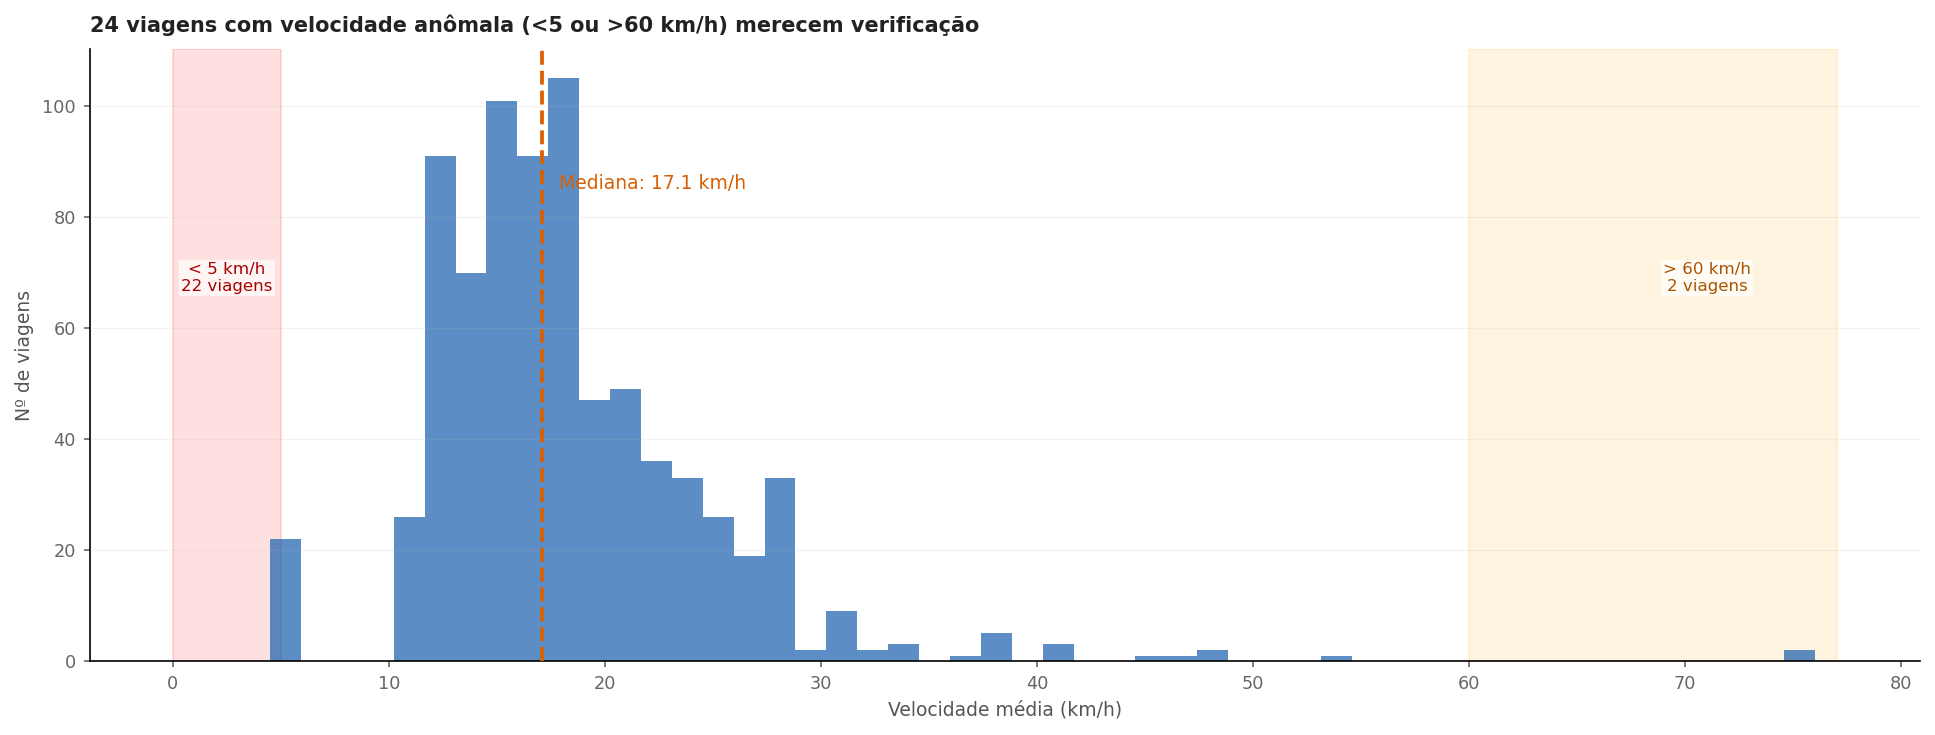


⚠  22 viagens com velocidade < 5 km/h (possível erro de dados):


,route_short_name,trip_id,distance_km,duration,speed_kmh
619,346,t-r346-sw_05:20:00_05:20:00_DU-05:20:00-1-0,1.9,0.4,4.5
620,346,t-r346-sw_06:10:00_06:10:00_DU-06:10:00-1-0,1.9,0.4,4.5
621,346,t-r346-sw_07:00:00_07:00:00_DU-07:00:00-1-0,1.9,0.4,4.5
622,346,t-r346-sw_07:50:00_07:50:00_DU-07:50:00-1-0,1.9,0.4,4.5
623,346,t-r346-sw_08:40:00_08:40:00_DU-08:40:00-1-0,1.9,0.4,4.5


In [52]:
# ── Distribuição de velocidades por viagem ──────────────────────────
# Schwabish §3: anotação direta no gráfico, sem legenda separada.
# Schwabish §1: zonas de anomalia com sombreamento transparente.
# Schwabish §3: título ativo destaca o dado relevante para diagnóstico.

ts_spd = (
    trip_stats
    .merge(feed.trips[["trip_id", "route_id"]])
    .merge(feed.routes[["route_id", "route_short_name"]])
)

spd = ts_spd["speed_kmh"].dropna()
med_spd = spd.median()
n_slow = int((spd < 5).sum())
n_fast = int((spd > 60).sum())
pct_ok = (((spd >= 5) & (spd <= 60)).sum() / len(spd) * 100)

fig, ax = plt.subplots(figsize=(13, 5))

ax.hist(spd, bins=50, color=PAL["primary"], edgecolor="none", alpha=0.75)

# Mediana: anotada diretamente (Schwabish §3 – sem legenda)
ymax = ax.get_ylim()[1]
ax.axvline(med_spd, color=PAL["secondary"], linewidth=1.8, linestyle="--", zorder=5)
ax.annotate(
    f"Mediana: {med_spd:.1f} km/h",
    xy=(med_spd, ymax * 0.78),
    xytext=(8, 0), textcoords="offset points",
    ha="left", va="center", fontsize=9, color=PAL["secondary"],
)

# Zonas de anomalia (Schwabish §1: mostrar o dado relevante)
if n_slow > 0:
    ax.axvspan(0, 5, alpha=0.12, color="red", zorder=0)
    ax.text(2.5, ymax * 0.60,
            f"< 5 km/h\n{n_slow} viagens", ha="center", va="bottom",
            fontsize=8, color="#AA0000",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1))
if n_fast > 0:
    ax.axvspan(60, spd.max() + 1, alpha=0.12, color="orange", zorder=0)
    ax.text(max(spd.max() - 5, 62), ymax * 0.60,
            f"> 60 km/h\n{n_fast} viagens", ha="center", va="bottom",
            fontsize=8, color="#AA5500",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1))

ax.set_xlabel("Velocidade média (km/h)")
ax.set_ylabel("Nº de viagens")
ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", alpha=0)

anomalies = n_slow + n_fast
ax.set_title(
    f"{anomalies} viagens com velocidade anômala (<5 ou >60 km/h) merecem verificação"
    if anomalies > 0 else
    f"{pct_ok:.0f}% das viagens opera entre 5 e 60 km/h — sem anomalias críticas",
    fontsize=10, fontweight="bold", loc="left", pad=8
)

plt.tight_layout()
plt.show()

if n_slow > 0:
    print(f"\n⚠  {n_slow} viagens com velocidade < 5 km/h (possível erro de dados):")
    display(
        ts_spd.nsmallest(5, "speed_kmh")
        [["route_short_name", "trip_id", "distance_km", "duration", "speed_kmh"]]
    )


### 7.2 Stop spacing

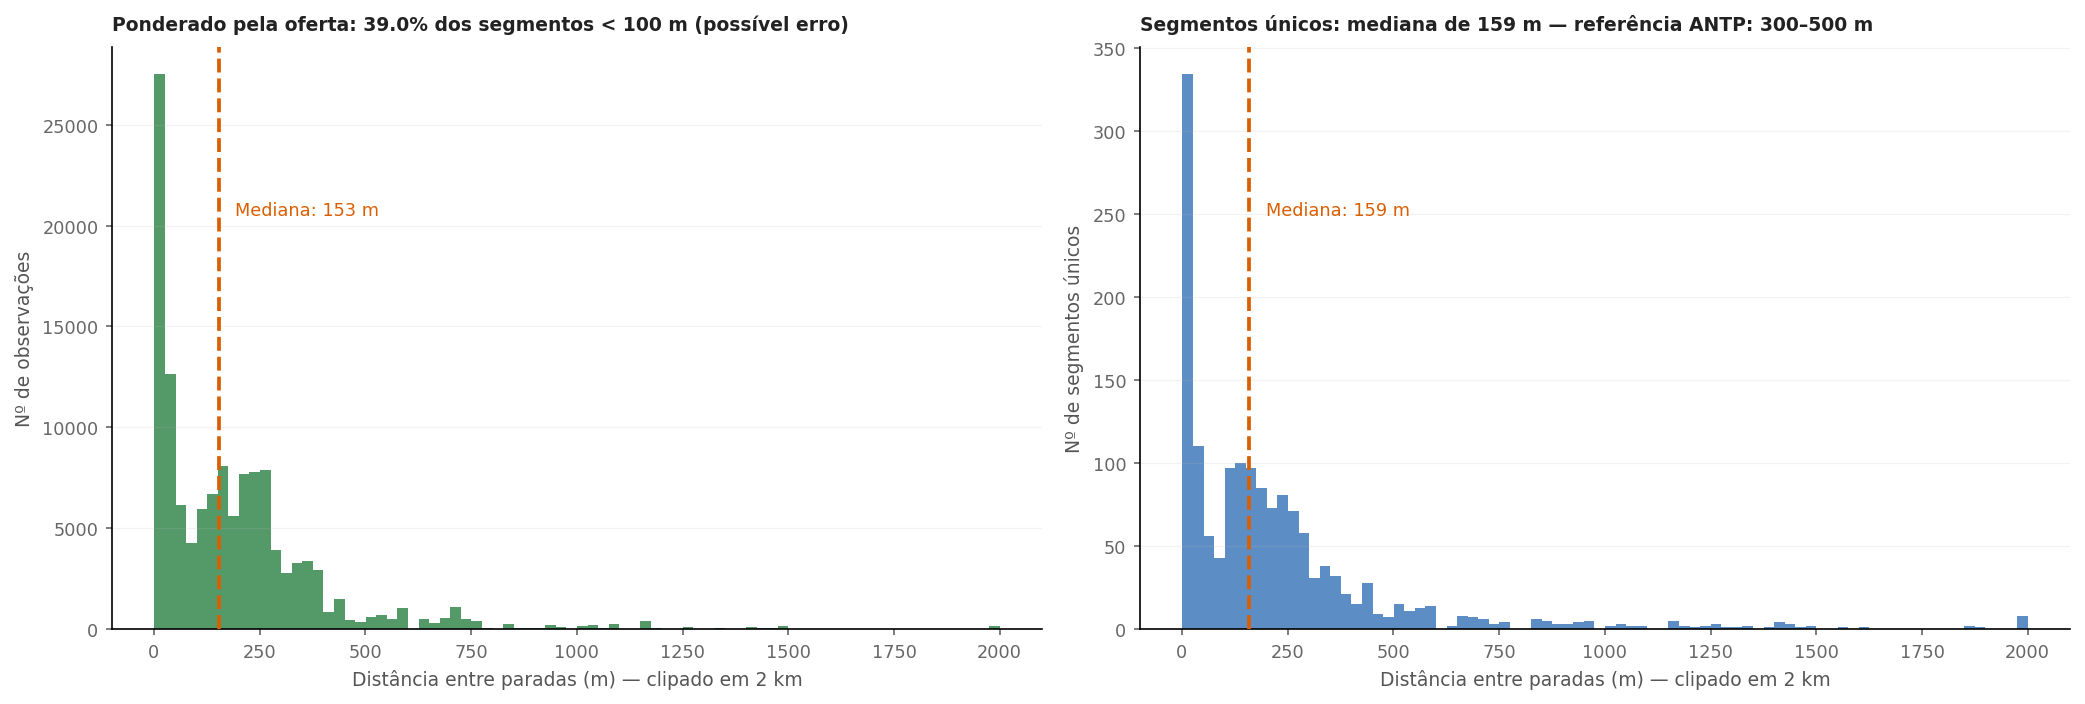

Mediana ponderada: 153 m | Mediana de únicos: 159 m
Ponderado > 2 km: 160 (0.1%)
Únicos    > 2 km: 8 (0.5%)


In [53]:
# ── Espaçamento entre paradas ───────────────────────────────────────
# Schwabish §3: anotação direta da mediana; sem legenda.
# Schwabish §4: dois painéis (small multiples) em vez de sobrepor séries.
# sharey=False: escalas independentes por ser distribuições distintas.

st_dist = feed.stop_times.copy()
st_dist = st_dist.sort_values(["trip_id", "stop_sequence"])
st_dist["next_stop_id"] = st_dist.groupby("trip_id")["stop_id"].shift(-1)
st_dist["next_dist"]    = st_dist.groupby("trip_id")["shape_dist_traveled"].shift(-1)
st_dist["segment_m"]    = st_dist["next_dist"] - st_dist["shape_dist_traveled"]
st_dist = st_dist.dropna(subset=["next_stop_id", "segment_m"]).copy()
st_dist = st_dist.loc[st_dist["segment_m"] > 0].copy()

seg_m_weighted = st_dist["segment_m"]

seg_unique = (
    st_dist
    .groupby(["stop_id", "next_stop_id"], as_index=False)
    .agg(segment_m=("segment_m", "median"), n_trips=("trip_id", "nunique"))
)
seg_m_unique = seg_unique["segment_m"]

med_w = seg_m_weighted.median()
med_u = seg_m_unique.median()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))

# ── Ponderado pela oferta ─────────────────────────────────────────────
ax1.hist(seg_m_weighted.clip(upper=2000), bins=80,
         color=PAL["accent"], edgecolor="none", alpha=0.75)
ax1.axvline(med_w, color=PAL["secondary"], linewidth=1.8, linestyle="--", zorder=5)
ylim1 = ax1.get_ylim()
ax1.annotate(f"Mediana: {med_w:.0f} m",
             xy=(med_w, ylim1[1] * 0.72),
             xytext=(8, 0), textcoords="offset points",
             ha="left", va="center", fontsize=8.5, color=PAL["secondary"])
ax1.set_xlabel("Distância entre paradas (m) — clipado em 2 km")
ax1.set_ylabel("Nº de observações")
pct_short_w = (seg_m_weighted < 100).mean() * 100
ax1.set_title(
    f"Ponderado pela oferta: {pct_short_w:.1f}% dos segmentos < 100 m (possível erro)",
    fontsize=9, fontweight="bold", loc="left", pad=8
)
ax1.grid(axis="y", alpha=0.18); ax1.grid(axis="x", alpha=0)

# ── Segmentos únicos ──────────────────────────────────────────────────
ax2.hist(seg_m_unique.clip(upper=2000), bins=80,
         color=PAL["primary"], edgecolor="none", alpha=0.75)
ax2.axvline(med_u, color=PAL["secondary"], linewidth=1.8, linestyle="--", zorder=5)
ylim2 = ax2.get_ylim()
ax2.annotate(f"Mediana: {med_u:.0f} m",
             xy=(med_u, ylim2[1] * 0.72),
             xytext=(8, 0), textcoords="offset points",
             ha="left", va="center", fontsize=8.5, color=PAL["secondary"])
ax2.set_xlabel("Distância entre paradas (m) — clipado em 2 km")
ax2.set_ylabel("Nº de segmentos únicos")
pct_short_u = (seg_m_unique < 100).mean() * 100
ax2.set_title(
    f"Segmentos únicos: mediana de {med_u:.0f} m — referência ANTP: 300–500 m",
    fontsize=9, fontweight="bold", loc="left", pad=8
)
ax2.grid(axis="y", alpha=0.18); ax2.grid(axis="x", alpha=0)

plt.tight_layout()
plt.show()

print(f"Mediana ponderada: {med_w:.0f} m | Mediana de únicos: {med_u:.0f} m")
print(f"Ponderado > 2 km: {(seg_m_weighted > 2000).sum()} "
      f"({(seg_m_weighted > 2000).mean()*100:.1f}%)")
print(f"Únicos    > 2 km: {(seg_m_unique > 2000).sum()} "
      f"({(seg_m_unique > 2000).mean()*100:.1f}%)")


### 7.3 Trip duration outliers

C:\Users\brand\AppData\Local\Temp\ipykernel_30896\2607587135.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


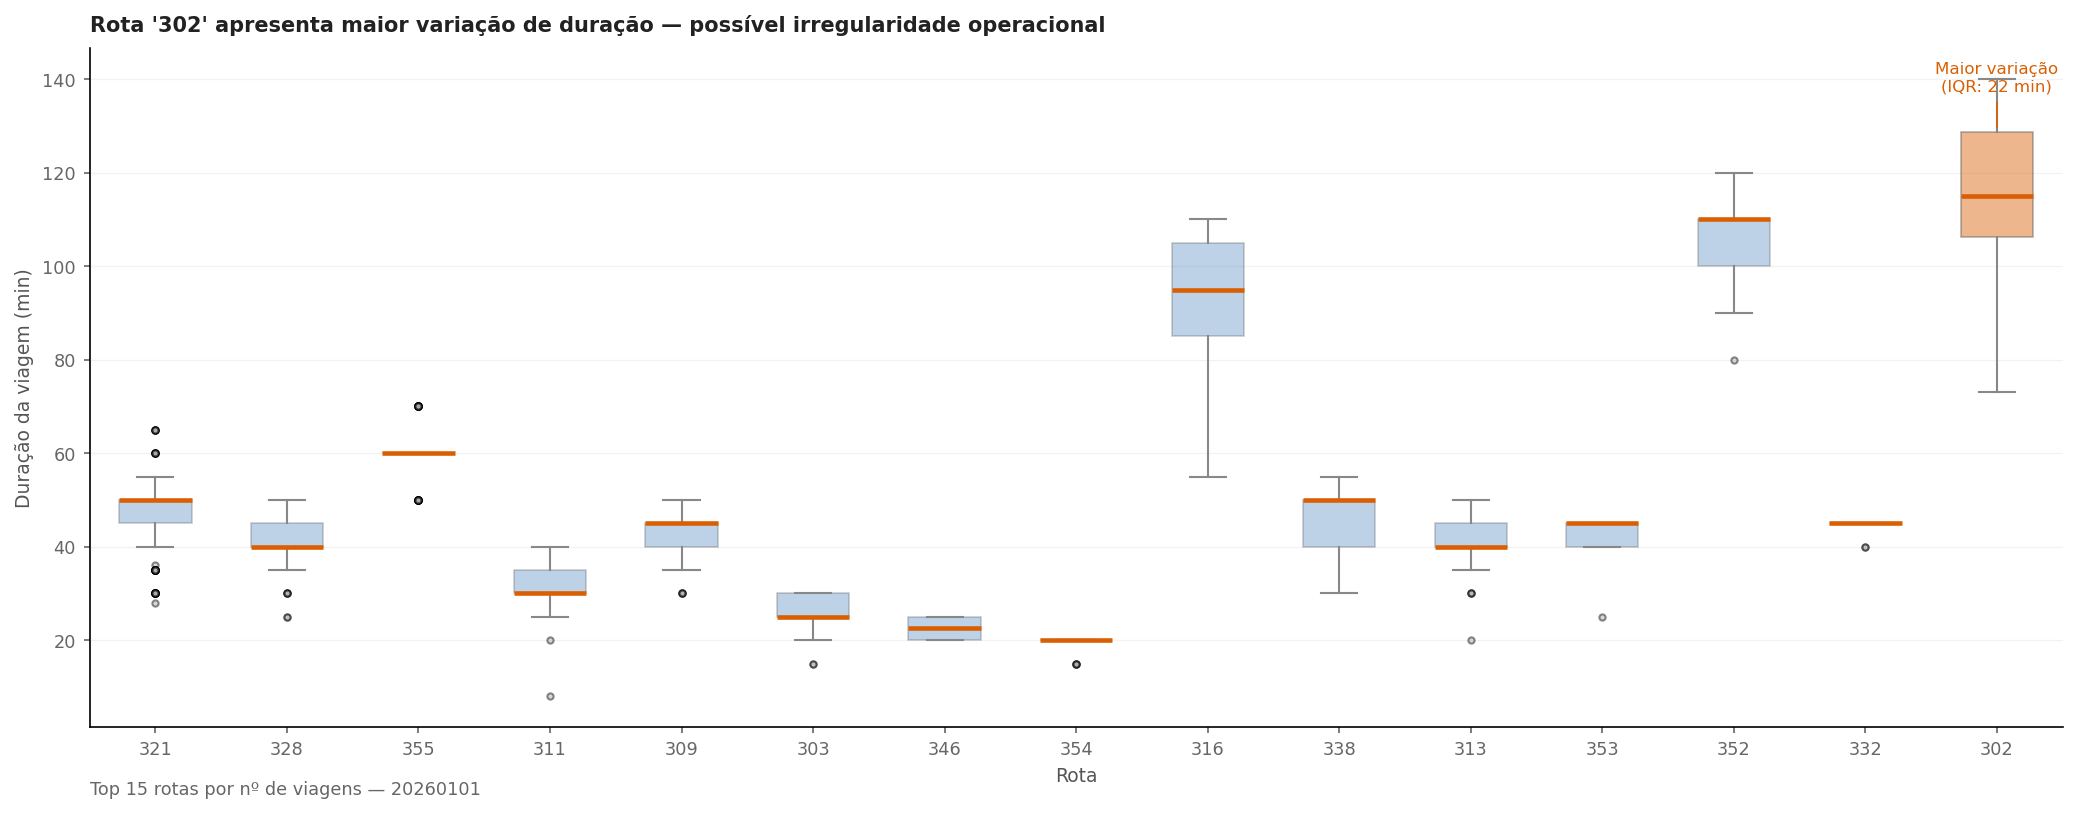

In [54]:
# ── Dispersão de duração por rota (top 15) ──────────────────────────
# Substitui px.box (Plotly) por matplotlib boxplot estático.
# Schwabish §2: estilo limpo, sem legenda (cores codificam categorias
#               mas os labels no eixo X já identificam cada rota).
# Schwabish §3: título ativo destaca o dado de interesse diagnóstico.
# Box horizontal opcional — descomente se os nomes de rota forem longos.

ts_dur = (
    trip_stats
    .merge(feed.trips[["trip_id", "route_id"]])
    .merge(feed.routes[["route_id", "route_short_name"]])
)
ts_dur["duration_min"] = ts_dur["duration"] * 60

top_routes  = ts_dur["route_short_name"].value_counts().head(15).index.tolist()
ts_dur_top  = ts_dur.loc[ts_dur["route_short_name"].isin(top_routes)]

# Dados por rota na mesma ordem
route_data = [
    ts_dur_top.loc[ts_dur_top["route_short_name"] == r, "duration_min"].values
    for r in top_routes
]

# Amplitude IQR máxima — destaque para rota mais variável (Schwabish §1)
iqrs = [np.percentile(d, 75) - np.percentile(d, 25) if len(d) > 1 else 0
        for d in route_data]
max_iqr_idx = int(np.argmax(iqrs))

fig, ax = plt.subplots(figsize=(14, 5.5))

bp = ax.boxplot(
    route_data,
    labels=top_routes,
    vert=True,
    patch_artist=True,
    widths=0.55,
    medianprops=dict(color=PAL["secondary"], linewidth=2.2, zorder=5),
    whiskerprops=dict(color="#888888", linewidth=1.0),
    capprops=dict(color="#888888", linewidth=1.0),
    flierprops=dict(marker="o", markerfacecolor=PAL["gray"],
                    markersize=3, alpha=0.45, linewidth=0),
)

# Schwabish §5: caixas em cinza, destaque apenas para a mais variável
for i, patch in enumerate(bp["boxes"]):
    if i == max_iqr_idx:
        patch.set_facecolor(PAL["secondary"])
        patch.set_alpha(0.45)
    else:
        patch.set_facecolor(PAL["primary"])
        patch.set_alpha(0.30)
    patch.set_edgecolor("#555555")
    patch.set_linewidth(0.8)

# Anotação da rota mais variável
ymax_val = max(np.percentile(d, 100) for d in route_data if len(d) > 0)
ax.annotate(
    f"Maior variação\n(IQR: {iqrs[max_iqr_idx]:.0f} min)",
    xy=(max_iqr_idx + 1, np.percentile(route_data[max_iqr_idx], 75)),
    xytext=(0, 18), textcoords="offset points",
    ha="center", va="bottom", fontsize=8, color=PAL["secondary"],
    arrowprops=dict(arrowstyle="-", color=PAL["secondary"], lw=0.8),
)

ax.set_xlabel("Rota")
ax.set_ylabel("Duração da viagem (min)")
ax.tick_params(axis="x", labelsize=8.5)
ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", alpha=0)

most_variable_route = top_routes[max_iqr_idx]
ax.set_title(
    f"Rota '{most_variable_route}' apresenta maior variação de duração"
    f" — possível irregularidade operacional",
    fontsize=10, fontweight="bold", loc="left", pad=8
)
ax.text(0, -0.10,
        f"Top 15 rotas por nº de viagens — {ANALYSIS_DATE}",
        transform=ax.transAxes, fontsize=8.5, color="#666666")

plt.tight_layout()
plt.show()


### 7.4 Feed completeness

In [55]:
# ── Check for common GTFS issues ────────────────────────────────────
checks = []

# Trips without stop_times
orphan_trips = set(feed.trips["trip_id"]) - set(feed.stop_times["trip_id"])
checks.append(("Viagens sem stop_times", len(orphan_trips),
               "✓" if not orphan_trips else f"⚠ {len(orphan_trips)}"))

# Stops without any visits
visited = set(feed.stop_times["stop_id"])
all_stops = set(feed.stops["stop_id"])
unused = all_stops - visited
checks.append(("Paradas sem visitas", len(unused),
               "✓" if not unused else f"⚠ {len(unused)}"))

# Routes without trips
routes_with_trips = set(feed.trips["route_id"])
all_routes = set(feed.routes["route_id"])
unused_routes = all_routes - routes_with_trips
checks.append(("Rotas sem viagens", len(unused_routes),
               "✓" if not unused_routes else f"⚠ {len(unused_routes)}"))

# Shapes coverage
if feed.shapes is not None:
    shapes_used = set(feed.trips["shape_id"].dropna())
    shapes_defined = set(feed.shapes["shape_id"])
    missing_shapes = shapes_used - shapes_defined
    checks.append(("Shapes faltando", len(missing_shapes),
                   "✓" if not missing_shapes else f"⚠ {len(missing_shapes)}"))

# Null arrival times
null_arr = feed.stop_times["arrival_time"].isna().sum()
checks.append(("stop_times sem arrival_time", null_arr,
               "✓" if null_arr == 0 else f"⚠ {null_arr}"))

# shape_dist_traveled coverage
null_dist = feed.stop_times["shape_dist_traveled"].isna().sum()
pct_null = null_dist / len(feed.stop_times) * 100
checks.append(("shape_dist_traveled nulo", null_dist,
               "✓" if pct_null < 1 else f"⚠ {null_dist} ({pct_null:.1f}%)"))

display(
    pd.DataFrame(checks, columns=["Verificação", "Contagem", "Status"])
    .style
    .applymap(lambda v: "color: green" if v == "✓" else "color: #D32F2F",
              subset=["Status"])
    .hide(axis="index")
    .set_caption("Diagnóstico de completude do feed")
)

Verificação,Contagem,Status
Viagens sem stop_times,0,✓
Paradas sem visitas,0,✓
Rotas sem viagens,0,✓
Shapes faltando,0,✓
stop_times sem arrival_time,0,✓
shape_dist_traveled nulo,0,✓


### 7.5 Route stats table (full)

In [56]:
# ── Full route stats via gtfs_kit ────────────────────────────────────
route_stats = feed.compute_route_stats(
    [ANALYSIS_DATE],
    headway_start_time=HEADWAY_START,
    headway_end_time=HEADWAY_END,
    split_directions=True,
).copy()

# O feed foi lido em metros; converte-se só na apresentação
if "service_distance" in route_stats.columns:
    route_stats["service_distance_km"] = route_stats["service_distance"] / DIST_FACTOR   # veja nota em célula 24
if "service_speed" in route_stats.columns:
    route_stats["service_speed_kmh"] = route_stats["service_speed"] / DIST_FACTOR

display_cols = [
    c for c in [
        "route_short_name",
        "route_id",
        "direction_id",
        "num_trips",
        "num_trip_starts",
        "mean_headway",
        "max_headway",
        "service_distance_km",
        "service_duration",
        "service_speed_kmh",
    ]
    if c in route_stats.columns
]

fmt = {}
if "max_headway" in display_cols:
    fmt["max_headway"] = "{:.0f}"
if "mean_headway" in display_cols:
    fmt["mean_headway"] = "{:.0f}"
if "service_distance_km" in display_cols:
    fmt["service_distance_km"] = "{:,.1f}"
if "service_duration" in display_cols:
    fmt["service_duration"] = "{:.1f}"
if "service_speed_kmh" in display_cols:
    fmt["service_speed_kmh"] = "{:.1f}"

sort_col = "service_distance_km" if "service_distance_km" in route_stats.columns else display_cols[0]

styled = (
    route_stats[display_cols]
    .sort_values(sort_col, ascending=False)
    .head(30)
    .style
    .format(fmt)
    .set_caption("Estatísticas de rotas por sentido (gtfs_kit)")
    .hide(axis="index")
)

if "service_distance_km" in display_cols:
    styled = styled.background_gradient(subset=["service_distance_km"], cmap="Blues")

display(styled)


route_short_name,route_id,direction_id,num_trips,num_trip_starts,mean_headway,max_headway,service_distance_km,service_duration,service_speed_kmh
321,r321,1,108,108,10,20,"1,430.6",83.7,17.1
321,r321,0,108,108,10,20,"1,148.6",85.5,13.4
355,r355,1,31,31,35,45,801.5,33.3,24.0
316,r316,0,16,16,72,120,652.2,24.8,26.3
352,r352,1,12,12,99,150,620.0,20.7,30.0
355,r355,0,31,31,35,35,614.1,28.7,21.4
316,r316,1,13,13,76,120,544.0,19.8,27.5
302,r302,1,9,9,135,140,510.7,15.9,32.2
302,r302,0,9,9,133,150,494.8,18.0,27.5
328,r328,1,40,40,26,40,486.7,27.3,17.8


---

### Notas metodológicas

- **Data de análise**: dia de maior atividade, detectado automaticamente nos primeiros 30 dias do feed.
- **Headways em parada**: calculados entre {HEADWAY_START}–{HEADWAY_END}, agregando sentidos.
- **Estatísticas por rota**: calculadas por sentido (`split_directions=True`) para evitar headways artificialmente baixos.
- **Unidades de distância e velocidade**: o fator `DIST_FACTOR` (célula 24) deve ser ajustado conforme o feed — 1 000 se `shape_dist_traveled` estiver em metros (típico em feeds brasileiros), 1 se já estiver em km.
- **Corredores**: o mapa agrega ida e volta no mesmo corredor (par não ordenado de paradas consecutivas).
- **Espaçamento entre paradas**: duas leituras — ponderado pela oferta programada e por segmentos únicos.
- **Figuras estáticas**: todos os gráficos usam `matplotlib`/`geopandas` para exportação em PDF/DOCX.  
  Para mapas com tiles de fundo (basemap), instale `contextily` e descomente as linhas `# ctx`.
- **Diretrizes visuais**: Schwabish, J. *Better Data Visualizations*. Columbia University Press, 2021.  
  Aplicadas: (1) mostrar o dado, (2) reduzir clutter, (3) integrar texto/gráfico, (4) evitar spaghetti, (5) começar com cinza.
- **Ferramentas**: `gtfs_kit` (análise GTFS), `matplotlib` + `geopandas` (gráficos estáticos).
